<a id="section-1"></a>
# PeMS dataset

Traffic dataset `PEMS-08 Dataset`, which contains the traffic data in San Bernardino from July to August in 2016. There are 170 locations with detectors recording every 5 minute intervals of traffic information. The dataset includes 3 features: `flow`, `occupy`, `speed`. The details of the features are as the following:

- The flow variable in the PEMS08 dataset represents the number of vehicles that pass through the loop detector per time interval (5 minutes in this case). It is measured in vehicles per 5-minute interval.

- The occupancy variable represents the proportion of time during the time interval (5 minutes) that the detector was occupied by a vehicle. It is measured as a percentage.

- The speed variable represents the average speed of the vehicles passing through the loop detector during the time interval (5 minutes). It is measured in miles per hour (mph).




<a id="section-2"></a>
# Import Libraries & Initialize Plots

In [ ]:
# Common libraries for data cleaning and visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from numpy import load # use to load an npz file
from scipy.signal import periodogram # use to graph a periodogram to get seasonality analysis
from sklearn.preprocessing import MinMaxScaler # use to normalize the data features

# keras library to create NN models
from keras.models import Sequential, Model, load_model
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras.utils import plot_model, to_categorical, Sequence,  get_custom_objects

# libraries for the metrics we will use (RMSE and Spearman)
from keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanSquaredError, MeanSquaredLogarithmicError, CosineSimilarity
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error, r2_score
from scipy.stats import spearmanr
import scipy.stats as stats

In [ ]:
# Set plot settings
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = 'both'
plt.rcParams['grid.alpha'] = 0.5

<a id="section-3"></a>
# Data Formatting
.npz is a file format used by the NumPy library to store arrays and metadata in a compressed format.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = load('/content/drive/MyDrive/PeMS dataset/PEMS08.npz')

In [ ]:
lst = data.files   # List the arrays in the .npz file
print(data[lst[0]].shape)
print(data[lst[0]])

(17856, 170, 3)
[[[1.330e+02 6.030e-02 6.580e+01]
  [2.100e+02 5.890e-02 6.960e+01]
  [1.240e+02 3.580e-02 6.580e+01]
  ...
  [7.400e+01 2.131e-01 6.530e+01]
  [9.400e+01 2.260e-02 6.800e+01]
  [6.000e+00 3.100e-03 6.500e+01]]

 [[1.140e+02 5.320e-02 6.690e+01]
  [1.850e+02 5.500e-02 6.850e+01]
  [1.190e+02 3.390e-02 6.500e+01]
  ...
  [7.300e+01 1.469e-01 3.720e+01]
  [8.400e+01 1.890e-02 6.870e+01]
  [4.000e+00 1.800e-03 6.500e+01]]

 [[1.400e+02 6.220e-02 6.680e+01]
  [1.710e+02 4.660e-02 6.990e+01]
  [1.070e+02 3.360e-02 6.380e+01]
  ...
  [7.000e+01 5.860e-02 3.400e+01]
  [8.200e+01 2.200e-02 6.700e+01]
  [4.000e+00 2.100e-03 6.490e+01]]

 ...

 [[1.200e+02 5.810e-02 6.330e+01]
  [1.760e+02 5.290e-02 6.680e+01]
  [1.190e+02 5.180e-02 5.610e+01]
  ...
  [4.700e+01 1.551e-01 3.220e+01]
  [9.100e+01 2.290e-02 6.640e+01]
  [3.000e+00 1.400e-03 6.530e+01]]

 [[1.020e+02 5.790e-02 6.140e+01]
  [1.650e+02 4.920e-02 6.720e+01]
  [1.330e+02 5.070e-02 5.890e+01]
  ...
  [9.700e+01 1.265e-01

The file gives a numpy array with dimensions (17856, 170, 3), which are in the form of (timesteps, location, features). For the 3 features, the order is `flow`,`occupy`,`speed`.

In [ ]:
#prepare traffic data from npz file:

traffic_data = data[lst[0]]
data_dict = []

# loop for every timestep and every location and add as a single row
for timestep in range(traffic_data.shape[0]):
    for location in range(traffic_data.shape[1]):
        data_dict.append({
            "timestep" : timestep+1,
            "location" : location,
            "flow"     : traffic_data[timestep][location][0],
            "occupy"   : traffic_data[timestep][location][1],
            "speed"    : traffic_data[timestep][location][2]
        })

We changed it into a list of dictionary. Each row represents a single timestep in a single location.

In [ ]:
df = pd.DataFrame(data_dict)
df.to_csv("traffic.csv", index=False)
df

,timestep,location,flow,occupy,speed
0,1,0,133.0,0.0603,65.8
1,1,1,210.0,0.0589,69.6
2,1,2,124.0,0.0358,65.8
3,1,3,145.0,0.0416,69.6
4,1,4,206.0,0.0493,69.4
...,...,...,...,...,...
3035515,17856,165,74.0,0.0233,68.9
3035516,17856,166,11.0,0.0082,64.0
3035517,17856,167,83.0,0.0273,59.1
3035518,17856,168,70.0,0.0188,66.6


In [ ]:
traffic = pd.read_csv("/content/traffic.csv")
print(len(traffic))
traffic.head()

3035520


,timestep,location,flow,occupy,speed
0,1,0,133.0,0.0603,65.8
1,1,1,210.0,0.0589,69.6
2,1,2,124.0,0.0358,65.8
3,1,3,145.0,0.0416,69.6
4,1,4,206.0,0.0493,69.4


<a id="section-4"></a>
# Data Visualization & EDA

The data consist of $17856 \cdot 170 = 3035520$ rows.

In [ ]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035520 entries, 0 to 3035519
Data columns (total 5 columns):
 #   Column    Dtype  
---  ------    -----  
 0   timestep  int64  
 1   location  int64  
 2   flow      float64
 3   occupy    float64
 4   speed     float64
dtypes: float64(3), int64(2)
memory usage: 115.8 MB


All of the data seem to be either integer or float, nothing out of the ordinarily here. `flow`, `occupy` and `speed` are numerical and continuous data.

In [ ]:
traffic.count()

timestep    3035520
location    3035520
flow        3035520
occupy      3035520
speed       3035520
dtype: int64

In [ ]:
traffic.isna().sum()

timestep    0
location    0
flow        0
occupy      0
speed       0
dtype: int64

Also nothing surprising here, and fortunately the data has no null values, so we don't need to impute any values.

In [ ]:
traffic.describe()

,timestep,location,flow,occupy,speed
count,3.035520e+06,3.035520e+06,3.035520e+06,3.035520e+06,3.035520e+06
mean,8.928500e+03,8.450000e+01,2.306807e+02,6.507109e-02,6.376300e+01
std,5.154584e+03,4.907393e+01,1.462170e+02,4.590215e-02,6.652010e+00
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
25%,4.464750e+03,4.200000e+01,1.100000e+02,3.570000e-02,6.260000e+01
50%,8.928500e+03,8.450000e+01,2.150000e+02,6.010000e-02,6.490000e+01
75%,1.339225e+04,1.270000e+02,3.340000e+02,8.390000e-02,6.740000e+01
max,1.785600e+04,1.690000e+02,1.147000e+03,8.955000e-01,8.230000e+01


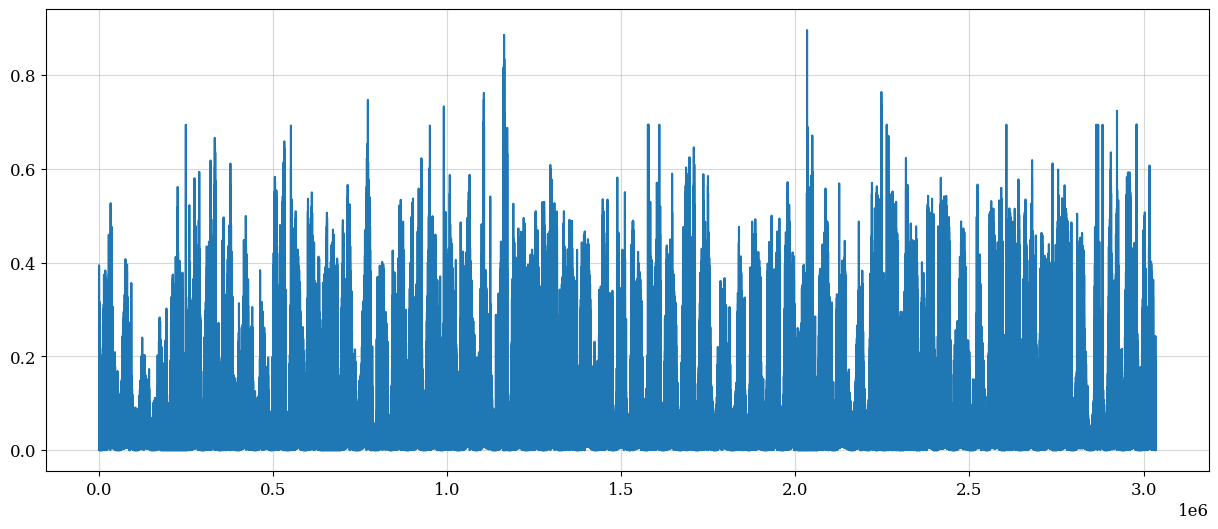

In [ ]:
# Plot a time series for a specific sensor
traffic['occupy'].plot(figsize=(15, 6))
plt.show()

1898734    1147.0
1898904    1099.0
1073724    1077.0
1315974    1052.0
1316144    1040.0
1316484    1033.0
1313254    1009.0
1314954     998.0
1898394     998.0
974274      995.0
Name: flow, dtype: float64


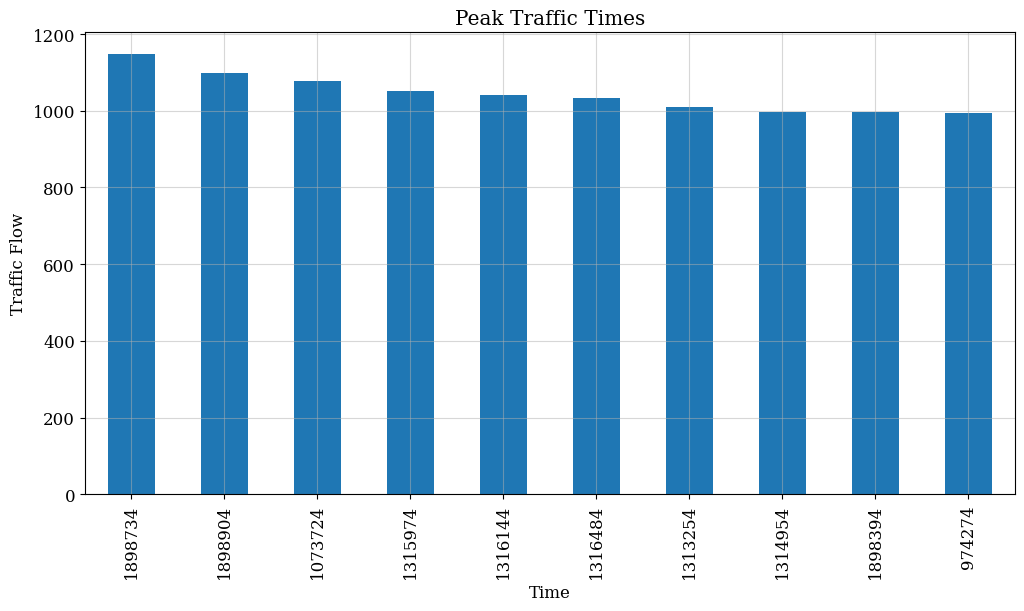

In [ ]:
# Identify peak traffic times
peak_times = traffic['flow'].nlargest(10)
print(peak_times)
# Plot peak times
peak_times.plot(kind='bar', figsize=(12, 6))
plt.title('Peak Traffic Times')
plt.xlabel('Time')
plt.ylabel('Traffic Flow')
plt.show()

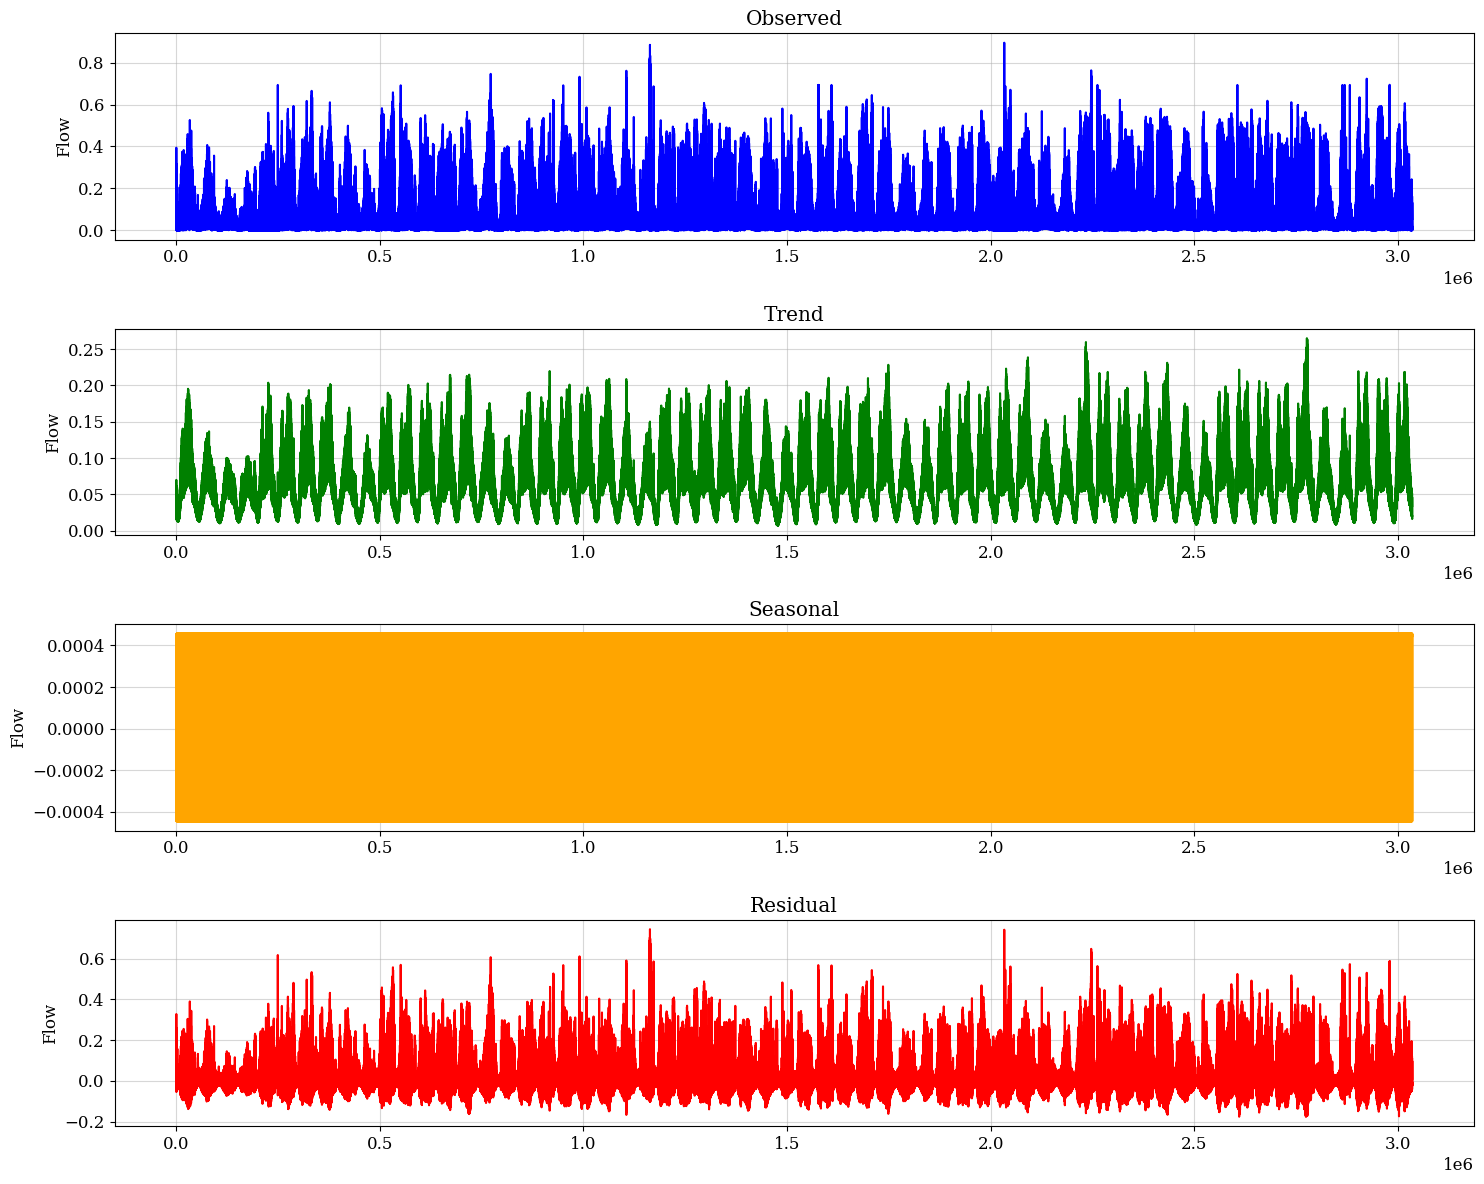

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series for a specific sensor
decomposition = seasonal_decompose(traffic['occupy'], model='additive', period=12)

# Plot the decomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12))
decomposition.observed.plot(ax=ax1, title='Observed', color='blue')
ax1.set_ylabel('Flow')
decomposition.trend.plot(ax=ax2, title='Trend', color='green')
ax2.set_ylabel('Flow')
decomposition.seasonal.plot(ax=ax3, title='Seasonal', color='orange')
ax3.set_ylabel('Flow')
decomposition.resid.plot(ax=ax4, title='Residual', color='red')
ax4.set_ylabel('Flow')
plt.tight_layout()
plt.show()

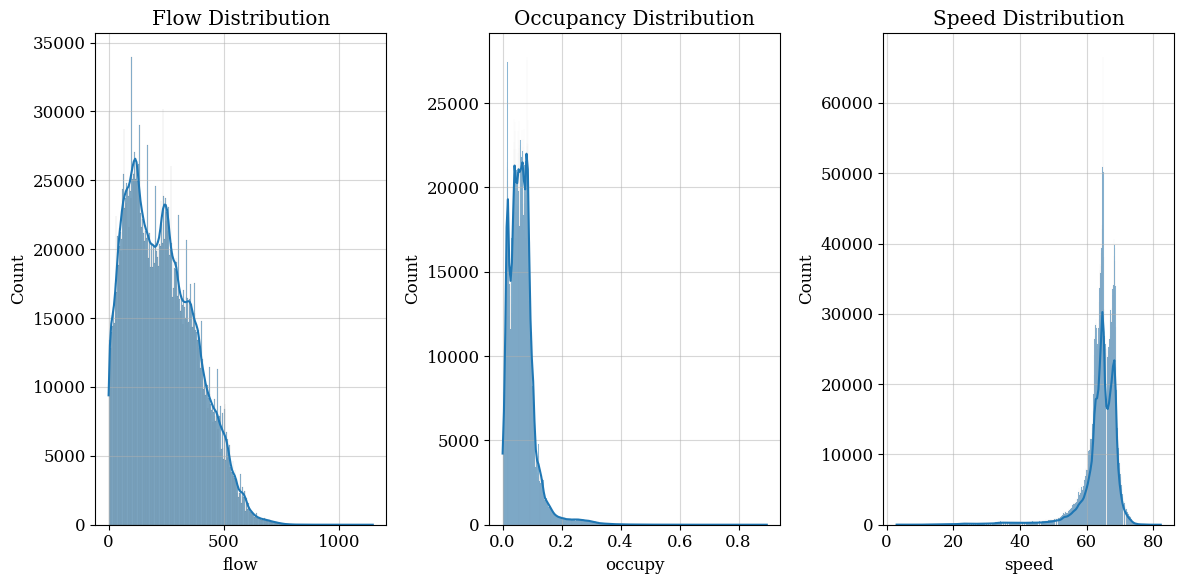

In [ ]:
# Plotting histograms
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.histplot(df['flow'], kde=True)
plt.title('Flow Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['occupy'], kde=True)
plt.title('Occupancy Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['speed'], kde=True)
plt.title('Speed Distribution')

plt.tight_layout()
plt.show()

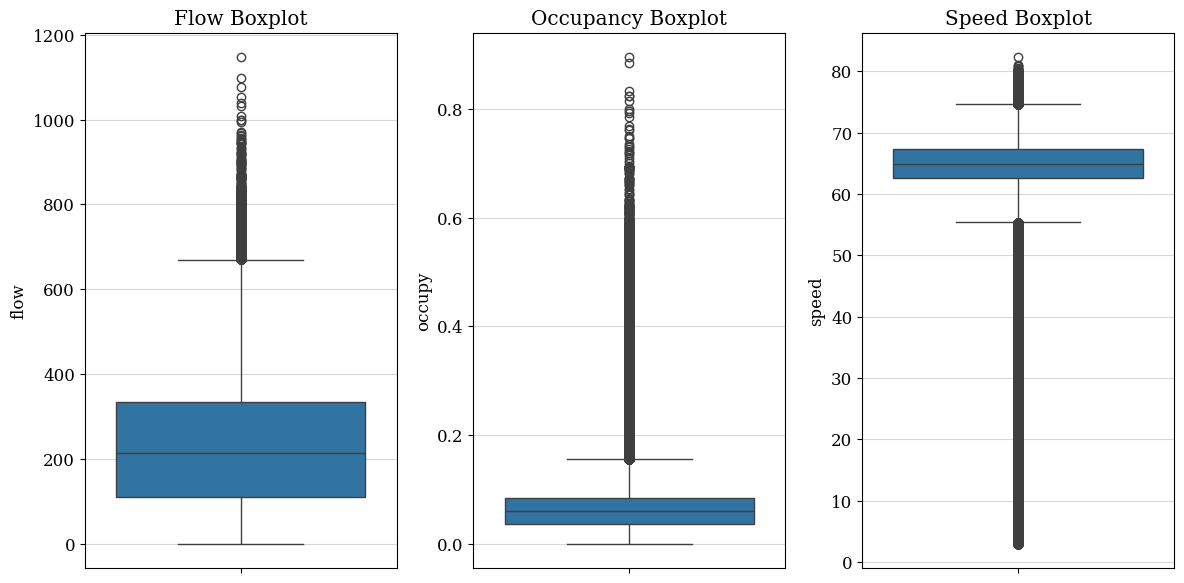

In [ ]:
# Boxplots to identify outliers
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['flow'])
plt.title('Flow Boxplot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['occupy'])
plt.title('Occupancy Boxplot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['speed'])
plt.title('Speed Boxplot')

plt.tight_layout()
plt.show()

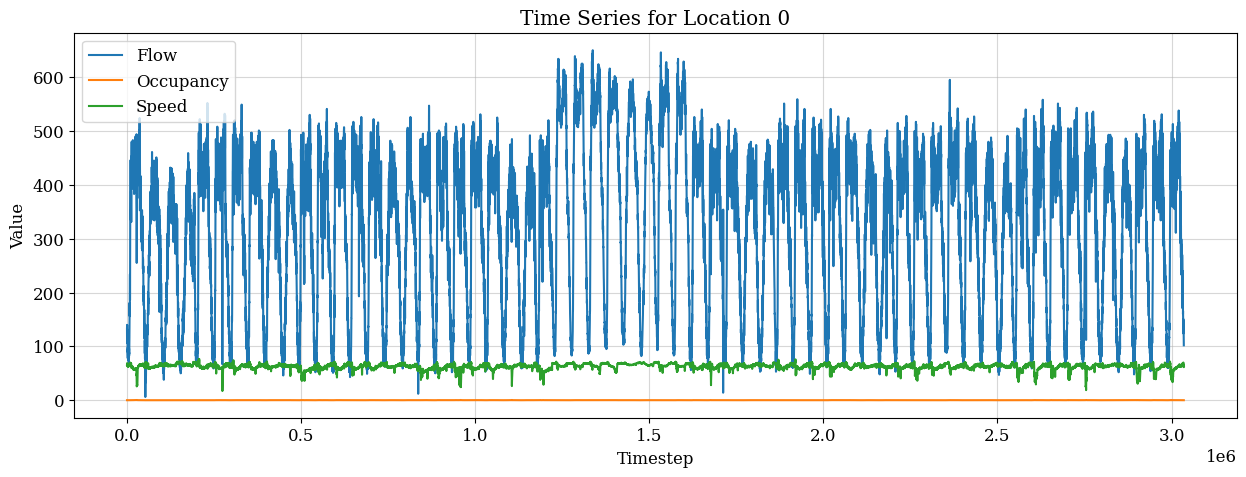

In [ ]:
# Time series plots
sample_location = 0  # Example location
plt.figure(figsize=(15, 5))
plt.plot(df[df['location'] == sample_location]['flow'], label='Flow')
plt.plot(df[df['location'] == sample_location]['occupy'], label='Occupancy')
plt.plot(df[df['location'] == sample_location]['speed'], label='Speed')
plt.legend()
plt.title('Time Series for Location {}'.format(sample_location))
plt.xlabel('Timestep')
plt.ylabel('Value')
plt.show()

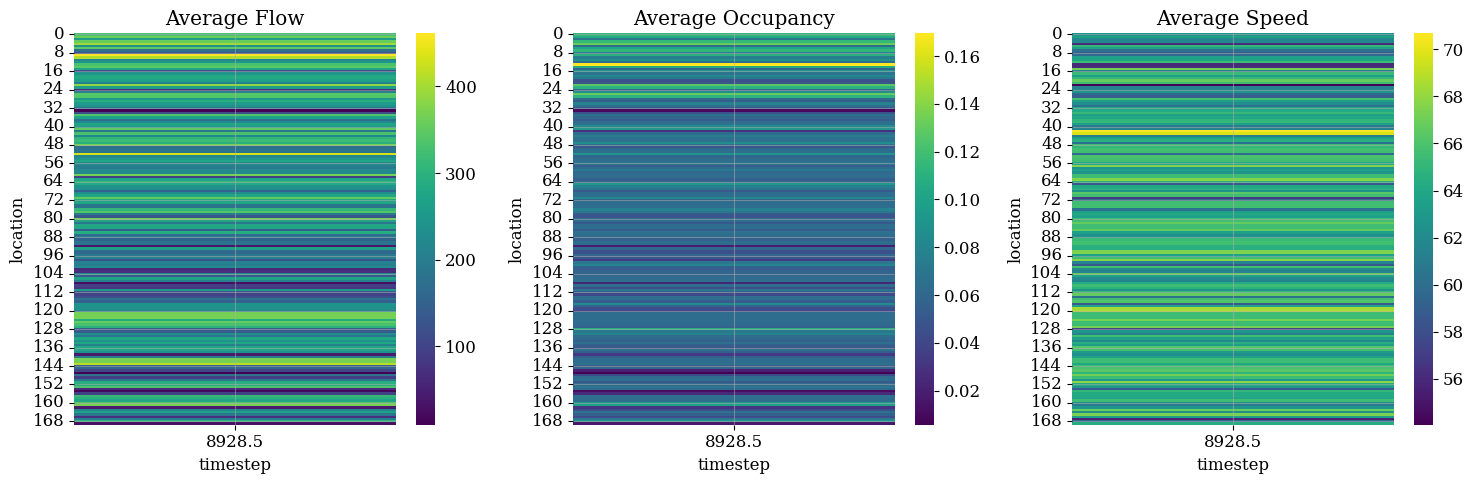

In [ ]:
# Heatmap for spatial distribution (average over time)
mean_values = df.groupby('location').mean().reset_index()

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.heatmap(mean_values.pivot(index='location', columns='timestep', values='flow'), cmap='viridis')
plt.title('Average Flow')

plt.subplot(1, 3, 2)
sns.heatmap(mean_values.pivot(index='location', columns='timestep', values='occupy'), cmap='viridis')
plt.title('Average Occupancy')

plt.subplot(1, 3, 3)
sns.heatmap(mean_values.pivot(index='location', columns='timestep', values='speed'), cmap='viridis')
plt.title('Average Speed')

plt.tight_layout()
plt.show()

In [ ]:
c# Correlation matrix
correlation_matrix = df[['flow', 'occupy', 'speed']].corr()
print(correlation_matrix)

            flow   occupy     speed
flow    1.000000  0.67404 -0.296332
occupy  0.674040  1.00000 -0.752040
speed  -0.296332 -0.75204  1.000000


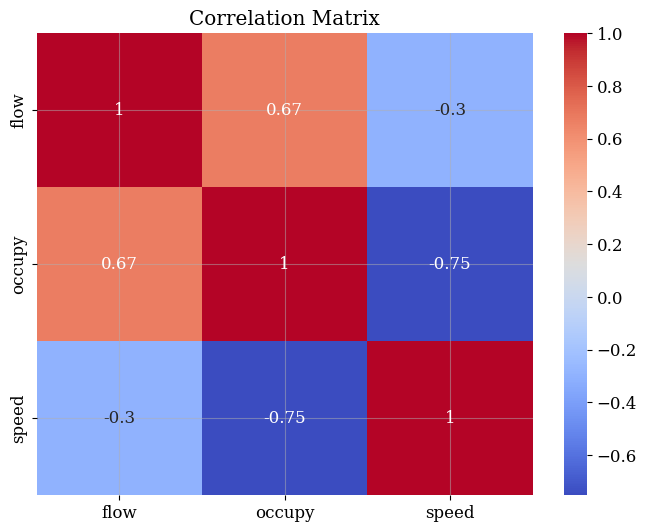

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Detect outliers using Z-score
from scipy.stats import zscore
df['flow_z'] = zscore(df['flow'])
df['occupy_z'] = zscore(df['occupy'])
df['speed_z'] = zscore(df['speed'])

outliers = df[(df['flow_z'].abs() > 3) | (df['occupy_z'].abs() > 3) | (df['speed_z'].abs() > 3)]
print("Number of outliers detected:", outliers.shape[0])

Number of outliers detected: 90755


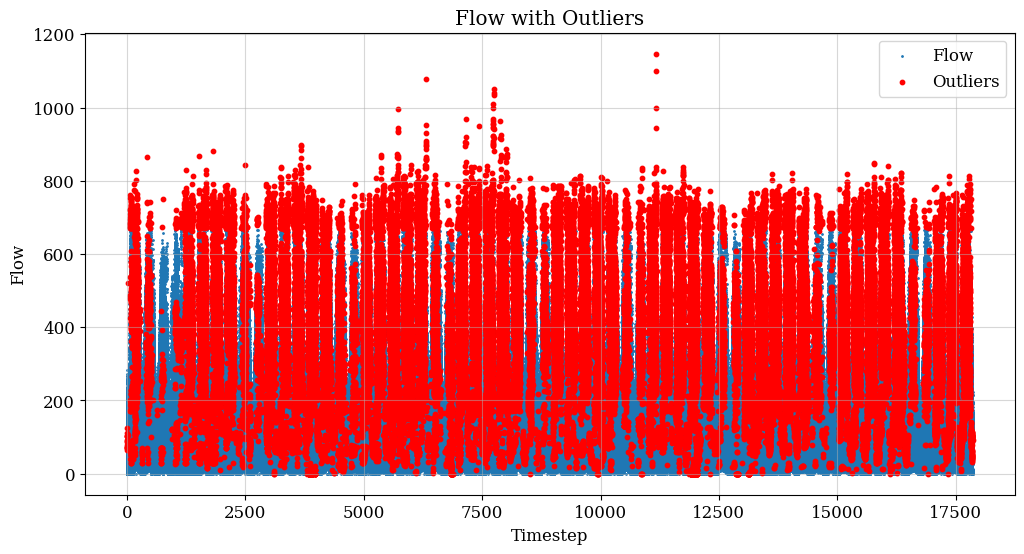

In [ ]:
# Plotting outliers
plt.figure(figsize=(12, 6))
plt.scatter(df['timestep'], df['flow'], s=1, label='Flow')
plt.scatter(outliers['timestep'], outliers['flow'], color='red', s=10, label='Outliers')
plt.legend()
plt.title('Flow with Outliers')
plt.xlabel('Timestep')
plt.ylabel('Flow')
plt.show()

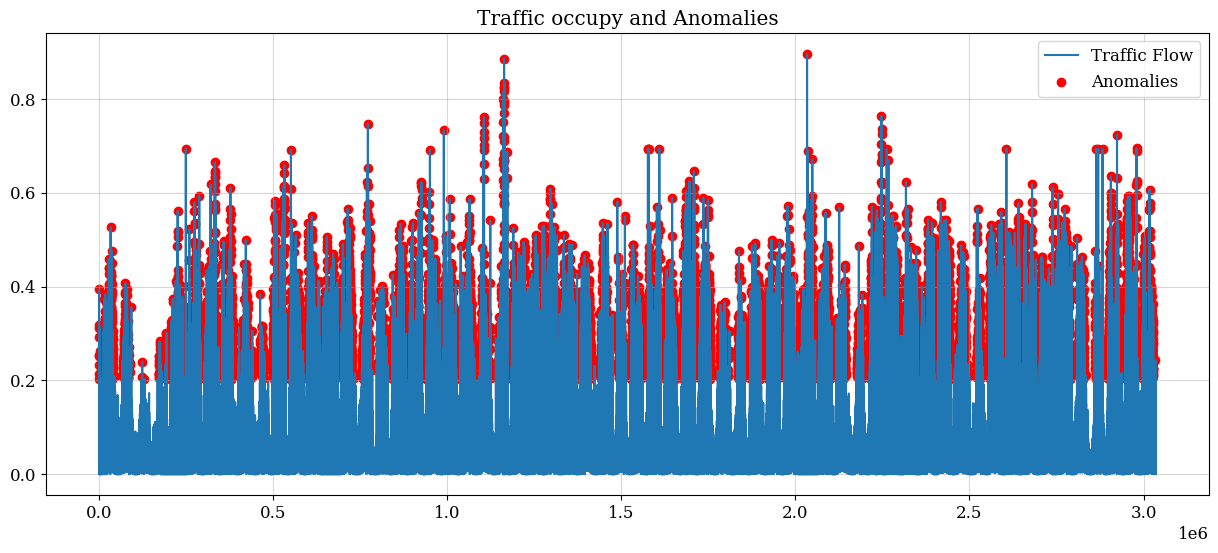

In [ ]:
from scipy import stats

# Calculate z-scores to identify anomalies
z_scores = stats.zscore(traffic['occupy'])
traffic['z_score'] = z_scores

# Filter anomalies
anomalies = traffic[traffic['z_score'].abs() > 3]

# Plot anomalies
plt.figure(figsize=(15, 6))
traffic['occupy'].plot(label='Traffic Flow')
plt.scatter(anomalies.index, anomalies['occupy'], color='red', label='Anomalies')
plt.title('Traffic occupy and Anomalies')
plt.legend()
plt.show()

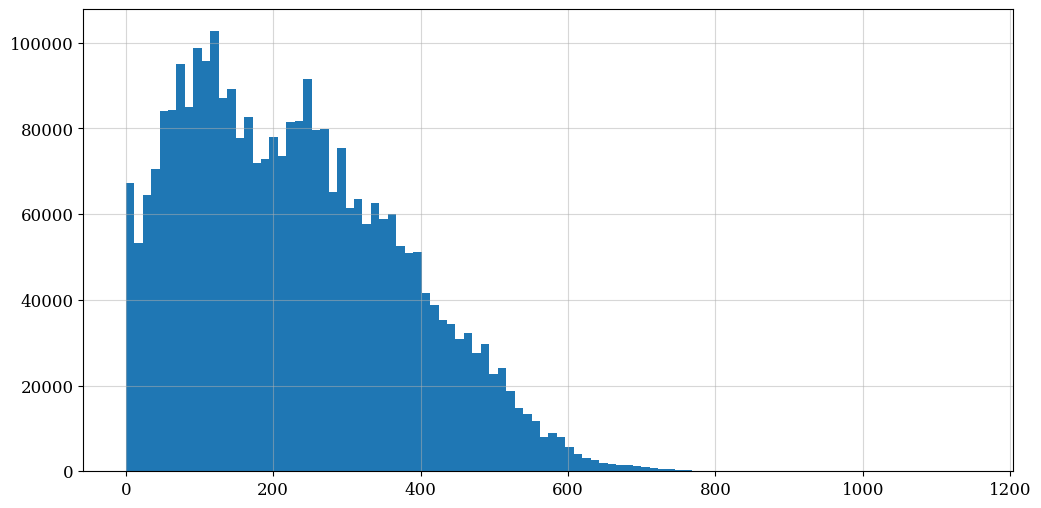

In [ ]:
traffic['flow'].hist(bins=100);

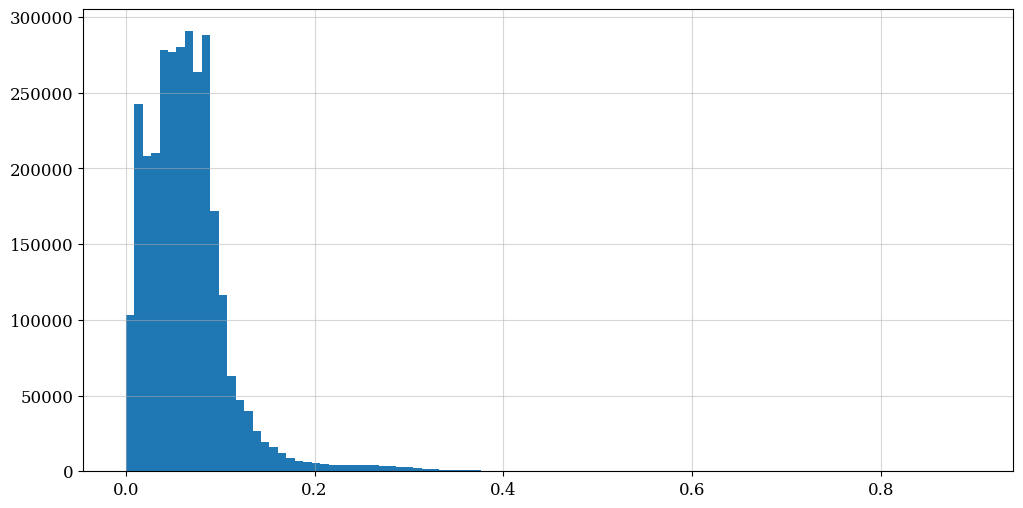

In [ ]:
traffic['occupy'].hist(bins=100);

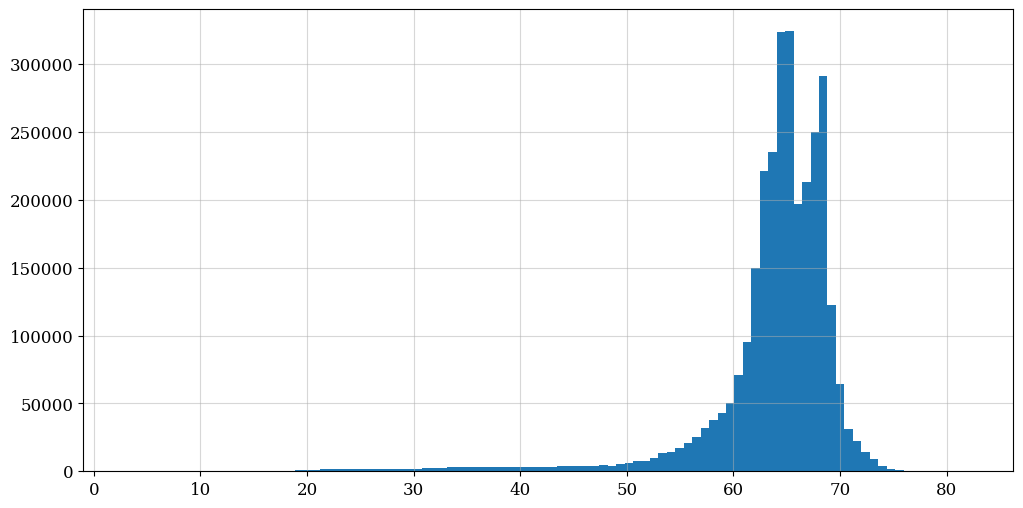

In [ ]:
traffic['speed'].hist(bins=100);

Looking at the distribution of `flow`, `occupy` and `speed`, it looks like they are spread out nicely and roughly follows a nice (a bit skewed) normal distribution. However, one thing to note is that the order of magnitude of the values are quite different, so we should normalize and scale the data later.

In [ ]:
#random location
location_0 = traffic[traffic["location"]==50].reset_index()
location_0.head()

,index,timestep,location,flow,occupy,speed
0,50,1,50,76.0,0.0262,69.5
1,220,2,50,81.0,0.0255,68.8
2,390,3,50,80.0,0.0243,69.0
3,560,4,50,76.0,0.0255,68.4
4,730,5,50,70.0,0.0224,68.1


<Axes: >

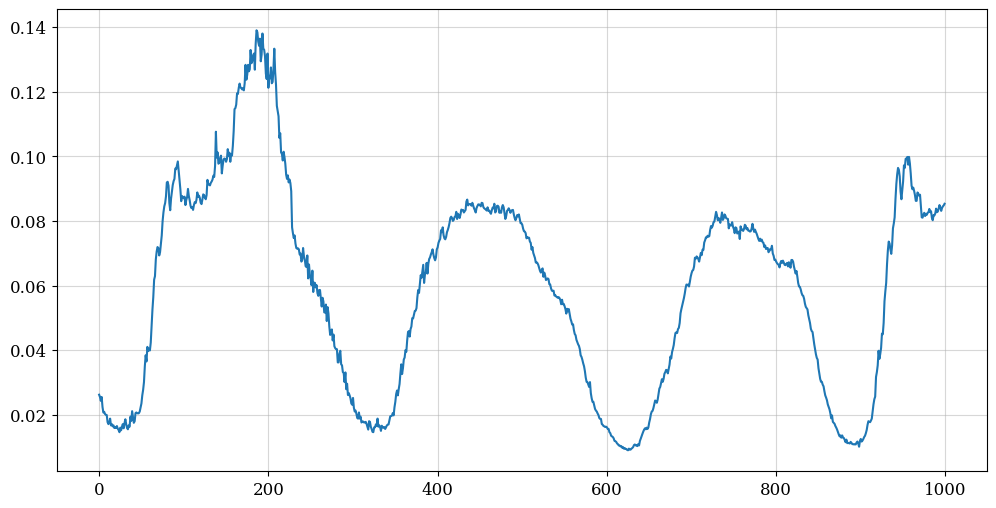

In [ ]:
location_0["occupy"][:1000].plot()

<Axes: >

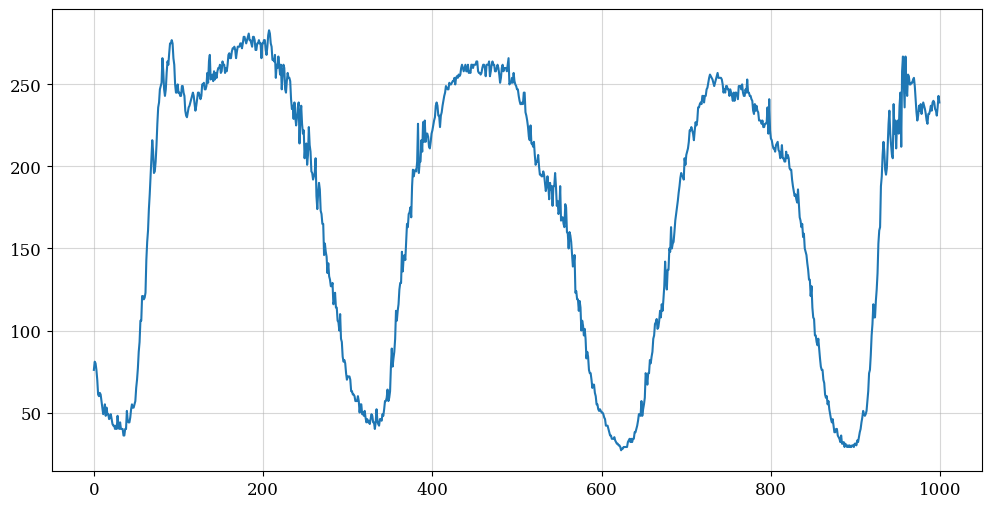

In [ ]:
location_0["flow"][:1000].plot()

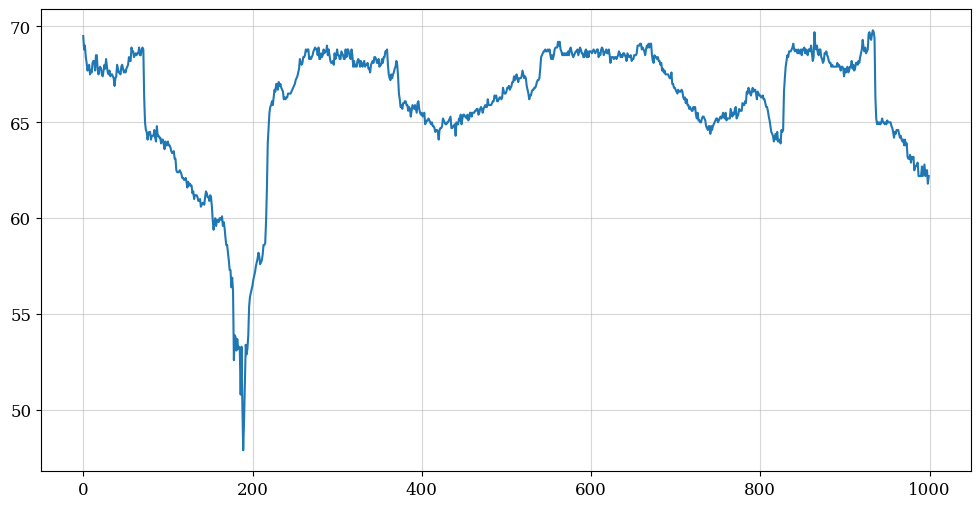

In [ ]:
location_0["speed"][:1000].plot();

In [ ]:
COR_STEP = 1    #Set the Correction Step:
pres = traffic[['flow', 'occupy', 'speed']][0:-(COR_STEP)].reset_index(drop=True)
future = traffic[['flow', 'occupy', 'speed']][COR_STEP:] \
    .reset_index(drop=True) \
    .add_suffix('_future')

val = pres.join(future)
val.corr()

,flow,occupy,speed,flow_future,occupy_future,speed_future
flow,1.000000,0.674039,-0.296332,0.535235,0.450192,-0.235030
occupy,0.674039,1.000000,-0.752040,0.445282,0.477379,-0.303858
speed,-0.296332,-0.752040,1.000000,-0.228266,-0.275180,0.233537
flow_future,0.535235,0.445282,-0.228266,1.000000,0.674040,-0.296331
occupy_future,0.450192,0.477379,-0.275180,0.674040,1.000000,-0.752040
speed_future,-0.235030,-0.303858,0.233537,-0.296331,-0.752040,1.000000


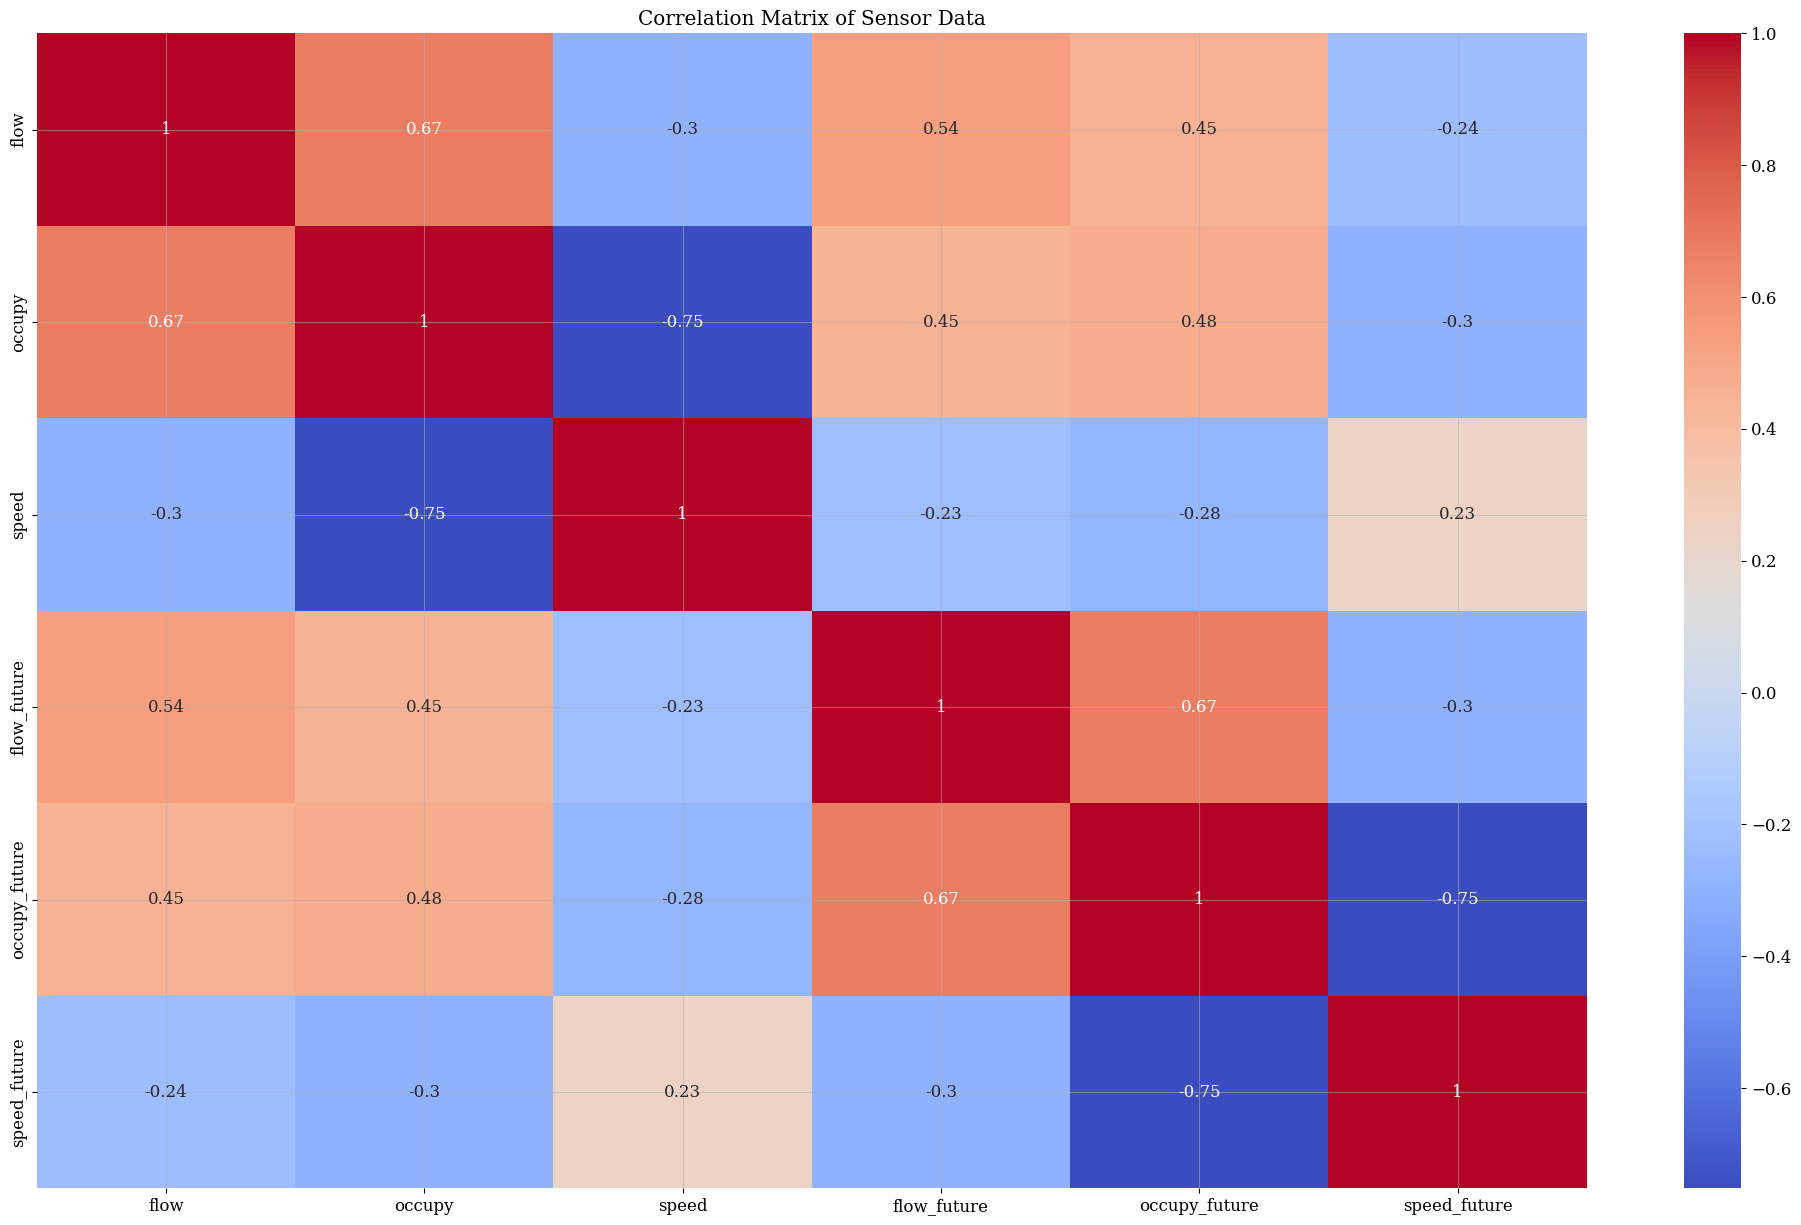

In [ ]:
# Compute the correlation matrix
correlation_matrix = val.corr()

# Plot the heatmap
plt.figure(figsize=(25,15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Sensor Data')
plt.show()

the correlation of all the variables to occupy is moderately high. In addition, it is also nice to see that the correlation of `flow` and `speed` to `occupy` is also high, which suggests that the variables might be linearly correlated and could be used to predict each other.

<Axes: title={'center': 'Periodogram'}, ylabel='Variance'>

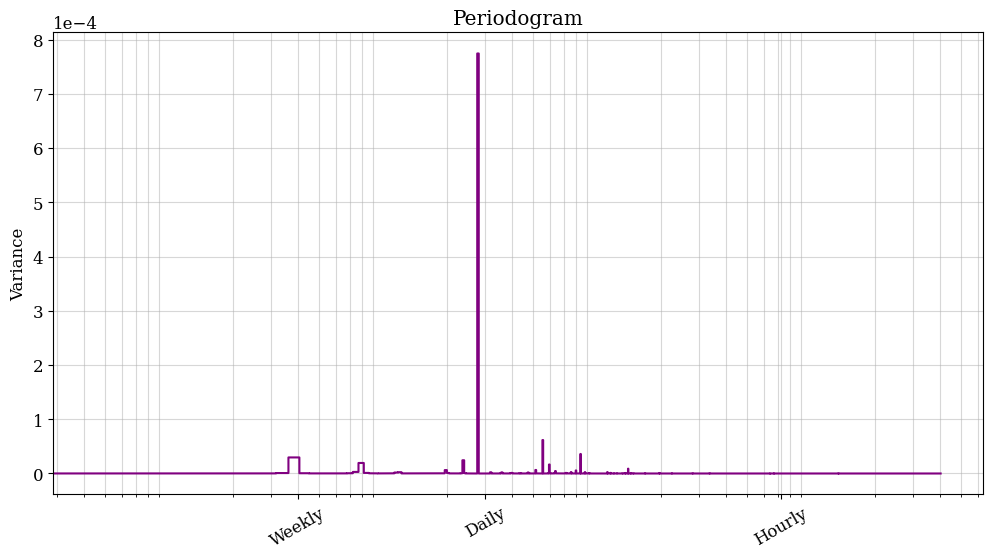

In [ ]:
#plot a periodogram to computes the frequency and spectrum:

def plot_periodogram(ts, detrend='linear', ax=None):
    """
    Plots the periodogram of a time series.

    Args:
        ts (pd.Series): A time series.
        detrend (str): Detrending method for the time series.
        ax (matplotlib.axes.Axes): The axes on which to plot.

    Returns:
        ax (matplotlib.axes.Axes): The axes on which the periodogram is plotted.
    """
    fs = pd.Timedelta(weeks=4) / pd.Timedelta(minutes=5)
    frequencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()

    ax.step(frequencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([4, 30, 30*24])
    ax.set_xticklabels(
        [
            "Weekly",
            "Daily",
            "Hourly"
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

plot_periodogram(location_0["occupy"])

 [periodogram](https://en.wikipedia.org/wiki/Periodogram) to test the seasonality of the `occupy` variable. The periodogram shows the strength of the frequencies present in the time series, and can be used to identify the dominant frequencies or periodicities in the data. From the graph above, it suggests that there seem to be a pattern in the occupy variable daily, which makes sense, since many people work and travel on a fixed schedule. (for example busy hours after work will have higher traffic) For this reason, we will add an `hour` feature on prediction.

In [ ]:
location_0["hour"] = ((location_0["timestep"] - 1) // 12)
grouped = location_0.groupby("hour").mean().reset_index()
grouped.head()

,hour,index,timestep,location,flow,occupy,speed
0,0,985.0,6.5,50.0,65.500000,0.021700,68.191667
1,1,3025.0,18.5,50.0,48.166667,0.016567,67.900000
2,2,5065.0,30.5,50.0,41.166667,0.016350,67.691667
3,3,7105.0,42.5,50.0,46.666667,0.019350,67.591667
4,4,9145.0,54.5,50.0,89.750000,0.031800,68.141667


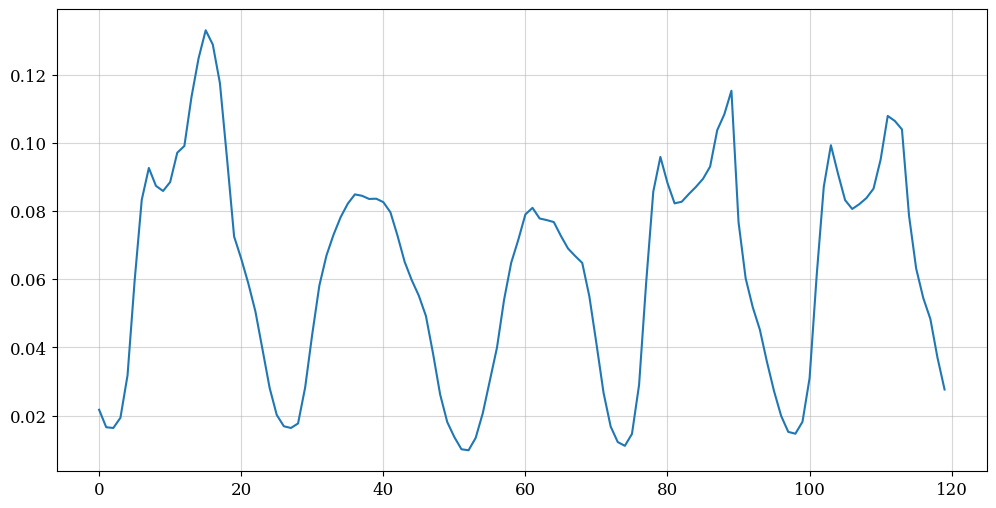

In [ ]:
grouped["occupy"][:24*5].plot();

In [ ]:
COR_STEP = 12
pres = grouped[['flow', 'occupy', 'speed']][0:-(COR_STEP)].reset_index(drop=True)
future = grouped[['flow', 'occupy', 'speed']][COR_STEP:] \
    .reset_index(drop=True) \
    .add_suffix('_future')
val = pres.join(future)
val.corr()

,flow,occupy,speed,flow_future,occupy_future,speed_future
flow,1.000000,0.966218,-0.718619,-0.722547,-0.707590,0.701991
occupy,0.966218,1.000000,-0.839110,-0.707282,-0.694619,0.686046
speed,-0.718619,-0.839110,1.000000,0.693508,0.681356,-0.599727
flow_future,-0.722547,-0.707282,0.693508,1.000000,0.966046,-0.718996
occupy_future,-0.707590,-0.694619,0.681356,0.966046,1.000000,-0.839682
speed_future,0.701991,0.686046,-0.599727,-0.718996,-0.839682,1.000000


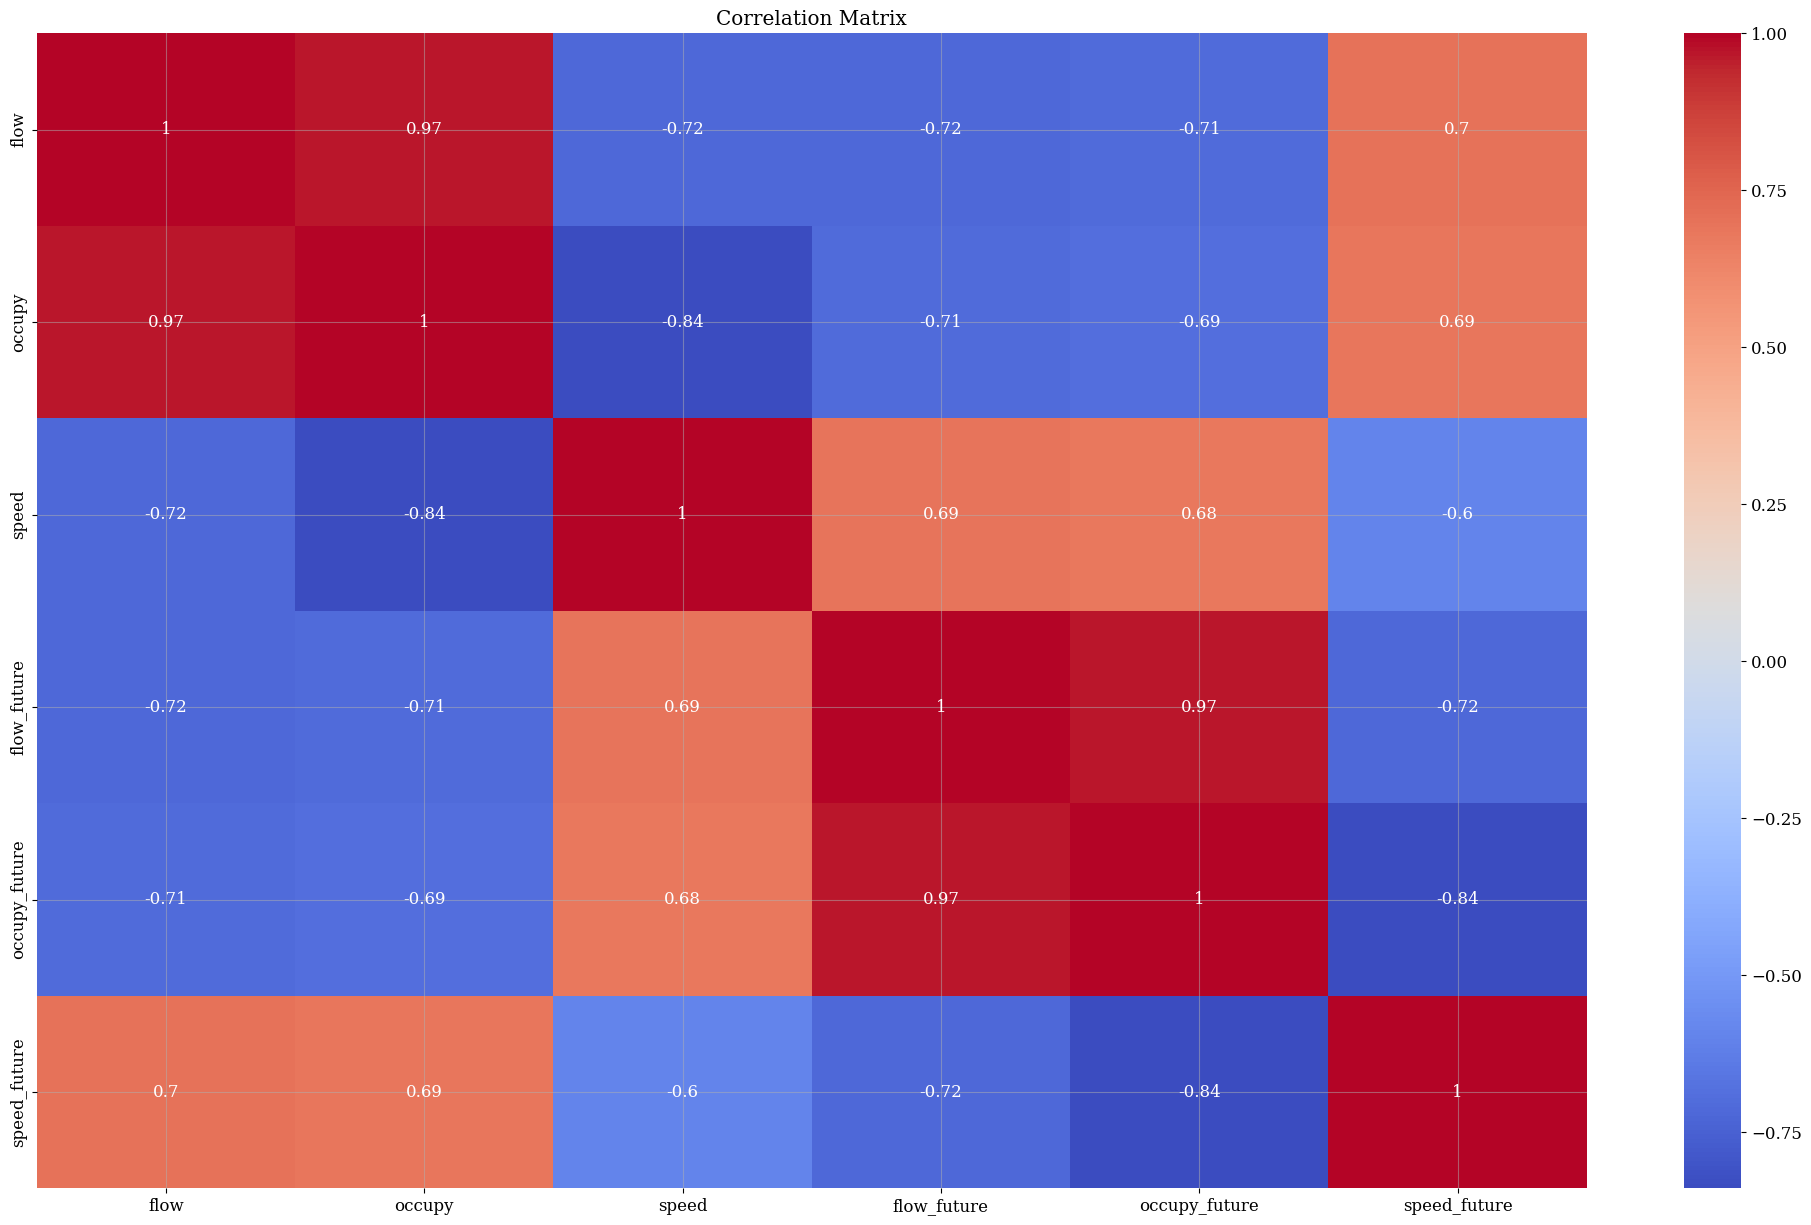

In [ ]:
# Compute the correlation matrix
correlation_matrix = val.corr()

# Plot the heatmap
plt.figure(figsize=(25,15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

<a id="section-5"></a>
# Data Preparation

In [ ]:
# creating 3-dimensional array for [timestep, timeframe, features]
def create_dataset(location, WINDOW_SIZE):

    # mask a certain location
    location_current = traffic[traffic["location"]==location].reset_index()

    # group to hour and average 12 (5-minute) timesteps
    location_current["hour"] = ((location_current["timestep"] - 1) // 12)
    grouped = location_current.groupby("hour").mean().reset_index()

    # add hour features as mod 24 cycle (0...23)
    grouped['day'] = (grouped['hour'] // 24) % 7
    grouped['hour'] %= 24

    one_hot_hour = pd.get_dummies(grouped['hour'])
    one_hot_hour = one_hot_hour.add_prefix('hour_')

    # merge all the features together to get a total of 27 features
    hour_grouped = pd.concat([grouped[["occupy", "flow", "speed"]], one_hot_hour], axis=1)
    hour_grouped = np.array(hour_grouped)

    X, Y = [], []

    # add lag features (in reverse time order)
    for i in range(len(hour_grouped) - WINDOW_SIZE):
        X.append(hour_grouped[i:(i + WINDOW_SIZE)][::-1]) # reverse the order
        Y.append(hour_grouped[i + WINDOW_SIZE, 0]) # index 0 is occupy

    return X,Y # returns (timestep, timeframe, features) and (target)

 `create_dataset` function to make all the features that we need for the prediction (hour features and lag features as multiple dimensions). Each lag step (lag steps total of WINDOW_SIZE) will be included to X in the second dimension (in reverse order). We format the array X as dimension (timestep, timeframe, features) and Y as dimension (target).

In [ ]:
# creating 4-th dimension for the locations
X, Y = [], []

for location in range(170):
    a,b = create_dataset(location, WINDOW_SIZE=24)
    X.append(a)
    Y.append(b)

X = np.moveaxis(X,0,-1)
Y = np.moveaxis(Y,0,-1)

print(X.shape)
print(Y.shape)

(1464, 24, 27, 170)
(1464, 170)


In [ ]:
print(X)

[[[[0.06932500000000001 0.082775 0.036725 ... 0.026408333333333325
    0.04186666666666666 0.007758333333333333]
   [197.66666666666666 313.75 174.5 ... 107.83333333333333
    174.33333333333334 15.666666666666666]
   [66.02499999999999 68.69166666666668 64.63333333333334 ... 71.325
    66.33333333333333 65.08333333333333]
   ...
   [False False False ... False False False]
   [False False False ... False False False]
   [True True True ... True True True]]

  [[0.08726666666666667 0.09854999999999998 0.044908333333333335 ...
    0.035366666666666664 0.057425000000000004 0.014400000000000001]
   [264.75 371.75 238.66666666666666 ... 148.25 240.16666666666666
    27.75]
   [66.25 69.05 65.26666666666667 ... 76.24166666666666
    67.50833333333334 64.85833333333333]
   ...
   [False False False ... False False False]
   [True True True ... True True True]
   [False False False ... False False False]]

  [[0.09986666666666666 0.11018333333333334 0.05456666666666667 ...
    0.0447249999999

 X `(timestep, timeframe, features, location)` and Y `(timestep, location)`.

In [ ]:
#split the data into train and test with `train : test` ratio of `0.8 : 0.2`.
#In a time series analysis, we don't usually use random splitting because it wont make sense to predict data in gaps,
#so we split the first 80% as train while the last 20% is used as test set.

TRAIN_SIZE = 0.8
TEST_SIZE  = 0.2

train_size = int(len(X) * TRAIN_SIZE)
test_size  = int(len(X) * TEST_SIZE)

train_X, train_Y = X[:train_size], Y[:train_size]
test_X, test_Y = X[train_size:], Y[train_size:]

print(train_X.shape)
print(train_Y.shape)
print(test_X.shape)
print(test_Y.shape)

(1171, 24, 27, 170)
(1171, 170)
(293, 24, 27, 170)
(293, 170)


In [ ]:
#`MinMaxScaler` to scale both X and Y features to the range (0,1)
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()
train_X = scaler_X.fit_transform(train_X.reshape(train_X.shape[0] * train_X.shape[1], -1)) \
                   .reshape(train_X.shape[0], train_X.shape[1], -1)
test_X = scaler_X.transform(test_X.reshape(test_X.shape[0] * test_X.shape[1], -1)) \
                   .reshape(test_X.shape[0], test_X.shape[1], -1)
train_Y = scaler_Y.fit_transform(train_Y)
test_Y = scaler_Y.transform(test_Y)

In [ ]:
print(train_X.shape)
print(test_X.shape)
print(train_Y.shape)
print(test_Y.shape)

(1171, 24, 4590)
(293, 24, 4590)
(1171, 170)
(293, 170)


<a id="section-6"></a>
# Model Training

## **1-Time Series Forecasting Statical Models**

# **a. ARIMA (AutoRegressive Integrated Moving Average)**

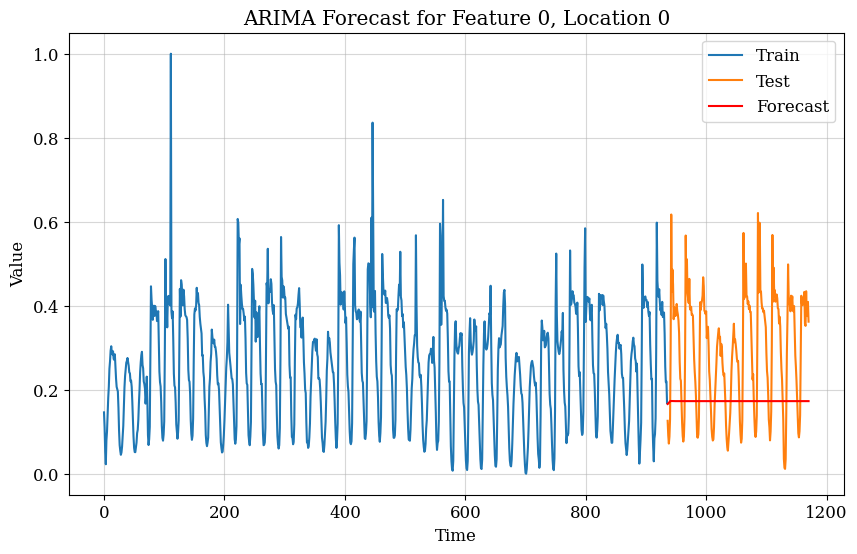

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Example: Extract time series for a specific feature and location
def extract_time_series(X, feature_idx, location_idx):
    # Check if X is 3D or 4D and adjust indexing accordingly
    if X.ndim == 3:
        return X[:, feature_idx, location_idx].reshape(-1)
    elif X.ndim == 4:
        return X[:, :, feature_idx, location_idx].reshape(-1)
    else:
        raise ValueError("Input array X must be either 3-dimensional or 4-dimensional.")

# Example ARIMA application to each location and feature
def fit_arima_to_all_series(X, feature_idx, location_idx):
    time_series = extract_time_series(X, feature_idx, location_idx)

    # Split into train and test
    train_size = int(len(time_series) * 0.8)
    train, test = time_series[:train_size], time_series[train_size:]

    # Fit ARIMA model
    model = ARIMA(train, order=(5, 1, 0))  # Adjust (p, d, q) as needed
    model_fit = model.fit()

    # Make predictions
    forecast = model_fit.forecast(steps=len(test))

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(len(train)), train, label='Train')
    plt.plot(np.arange(len(train), len(train) + len(test)), test, label='Test')
    plt.plot(np.arange(len(train), len(train) + len(test)), forecast, label='Forecast', color='red')
    plt.title(f'ARIMA Forecast for Feature {feature_idx}, Location {location_idx}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    return model_fit
# Example usage: Fit ARIMA model for flow feature at location 0
model_fit = fit_arima_to_all_series(train_X, feature_idx=0, location_idx=0)


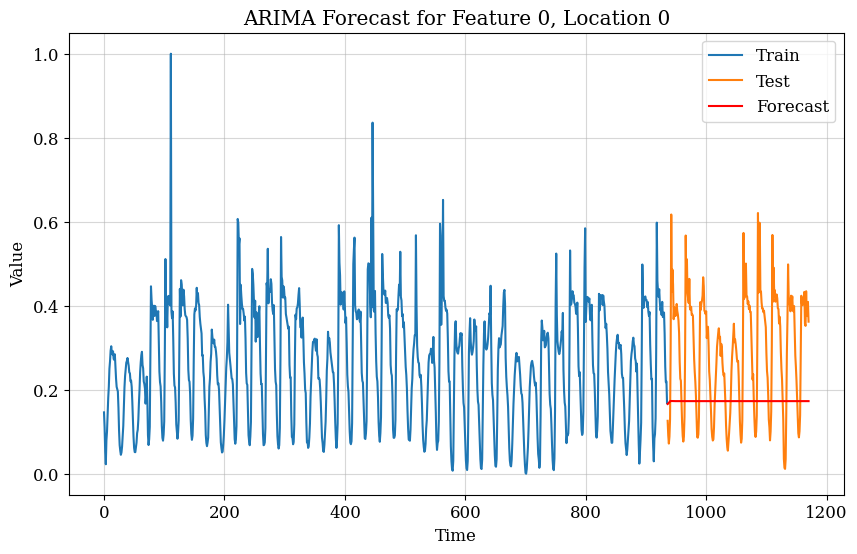

MAE: 0.1554
MSE: 0.0332
RMSE: 0.1822
MAPE: 0.6610


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def fit_and_evaluate_arima(X, feature_idx, location_idx):
    time_series = extract_time_series(X, feature_idx, location_idx)

    # Split into train and test
    train_size = int(len(time_series) * 0.8)
    train, test = time_series[:train_size], time_series[train_size:]

    # Fit ARIMA model
    model = ARIMA(train, order=(5, 1, 0))  # Adjust (p, d, q) as needed
    model_fit = model.fit()

    # Make predictions
    forecast = model_fit.forecast(steps=len(test))

    # Calculate evaluation metrics
    mae = mean_absolute_error(test, forecast)
    mse = mean_squared_error(test, forecast)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(test, forecast)

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(len(train)), train, label='Train')
    plt.plot(np.arange(len(train), len(train) + len(test)), test, label='Test')
    plt.plot(np.arange(len(train), len(train) + len(test)), forecast, label='Forecast', color='red')
    plt.title(f'ARIMA Forecast for Feature {feature_idx}, Location {location_idx}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    return model_fit, forecast, mae, mse, rmse, mape

# Example usage: Evaluate ARIMA model for flow feature at location 0
model_fit, forecast, mae, mse, rmse, mape = fit_and_evaluate_arima(train_X, feature_idx=0, location_idx=0)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")


In [ ]:
results = []
for feature_idx in range(train_X.shape[1]):
    for location_idx in range(train_X.shape[2]):
        #model_fit, forecast, mae, mse, rmse, mape = fit_and_evaluate_arima(train_X, feature_idx, location_idx)
        results.append({
            'Feature': feature_idx,
            'Location': location_idx,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'MAPE': mape
        })

results_df = pd.DataFrame(results)
print(results_df)


        Feature  Location       MAE       MSE      RMSE      MAPE
0             0         0  0.084128  0.018755  0.136948  0.293118
1             0         1  0.084128  0.018755  0.136948  0.293118
2             0         2  0.084128  0.018755  0.136948  0.293118
3             0         3  0.084128  0.018755  0.136948  0.293118
4             0         4  0.084128  0.018755  0.136948  0.293118
...         ...       ...       ...       ...       ...       ...
110155       23      4585  0.084128  0.018755  0.136948  0.293118
110156       23      4586  0.084128  0.018755  0.136948  0.293118
110157       23      4587  0.084128  0.018755  0.136948  0.293118
110158       23      4588  0.084128  0.018755  0.136948  0.293118
110159       23      4589  0.084128  0.018755  0.136948  0.293118

[110160 rows x 6 columns]


# **b. SARIMA (Seasonal ARIMA)**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Select a single location and feature (e.g., 'occupy')
location = 0
feature = 'occupy'

# Filter and reshape data
data_series = traffic[traffic['location'] == location][feature].reset_index(drop=True)

# Define SARIMA model
model = SARIMAX(data_series,
                 order=(1, 1, 1),  # (p, d, q)
                 seasonal_order=(1, 1, 1, 24),  # (P, D, Q, s) where s is the season length (24 hours in this case)
                 enforce_stationarity=False,
                 enforce_invertibility=False)

# Fit the model
results = model.fit(disp=False)

# Print model summary
print(results.summary())


                                     SARIMAX Results                                      
Dep. Variable:                             occupy   No. Observations:                17856
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               49407.638
Date:                            Wed, 07 Aug 2024   AIC                         -98805.275
Time:                                    18:50:26   BIC                         -98766.339
Sample:                                         0   HQIC                        -98792.464
                                          - 17856                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4097      0.007     57.092      0.000       0.396       0.424
ma.L1         -0.6615      0.006   

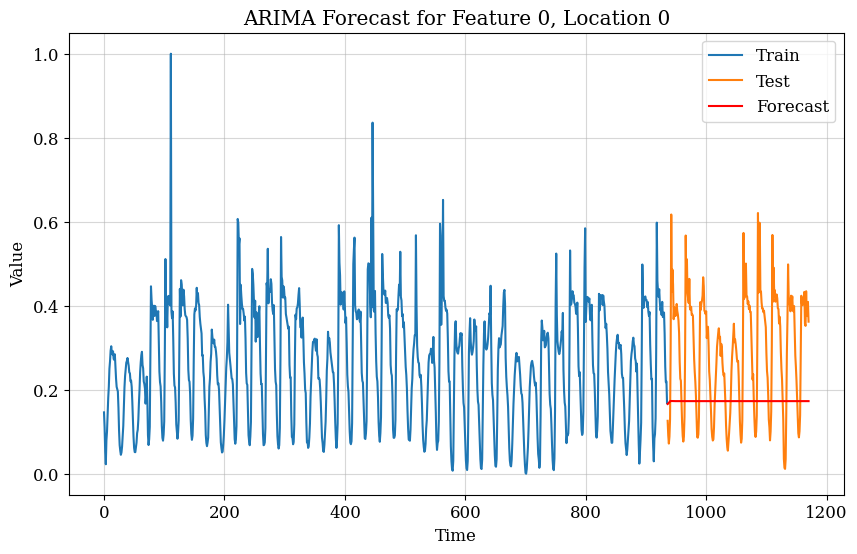

MAE: 0.1554
MSE: 0.0332
RMSE: 0.1822
MAPE: 0.6610


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Example: Extract time series for a specific feature and location
def extract_time_series(X, feature_idx, location_idx):
    # Check if X is 3D or 4D and adjust indexing accordingly
    if X.ndim == 3:
        return X[:, feature_idx, location_idx].reshape(-1)
    elif X.ndim == 4:
        return X[:, :, feature_idx, location_idx].reshape(-1)
    else:
        raise ValueError("Input array X must be either 3-dimensional or 4-dimensional.")
def fit_and_evaluate_arima(X, feature_idx, location_idx):
    time_series = extract_time_series(X, feature_idx, location_idx)

    # Split into train and test
    train_size = int(len(time_series) * 0.8)
    train, test = time_series[:train_size], time_series[train_size:]

    # Fit ARIMA model
    model = SARIMAX(train, order=(5, 1, 0))  # Adjust (p, d, q) as needed
    model_fit = model.fit()

    # Make predictions
    forecast = model_fit.forecast(steps=len(test))

    # Calculate evaluation metrics
    mae = mean_absolute_error(test, forecast)
    mse = mean_squared_error(test, forecast)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(test, forecast)

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(len(train)), train, label='Train')
    plt.plot(np.arange(len(train), len(train) + len(test)), test, label='Test')
    plt.plot(np.arange(len(train), len(train) + len(test)), forecast, label='Forecast', color='red')
    plt.title(f'ARIMA Forecast for Feature {feature_idx}, Location {location_idx}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    return model_fit, forecast, mae, mse, rmse, mape

# Example usage: Evaluate ARIMA model for flow feature at location 0
model_fit, forecast, mae, mse, rmse, mape = fit_and_evaluate_arima(train_X, feature_idx=0, location_idx=0)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")


# **c.Historical Average (HA)**

In [ ]:
# Assuming X_train, y_train, X_test, y_test are already defined
ha_model = HistoricalAverage()
# Fit the model on the training data (y_train, not train_X)
ha_model.fit(train_X, train_Y)
ha_predictions = ha_model.predict(test_Y)

# Check the shapes
print(f"test_Y shape: {test_Y.shape}")
print(f"ha_predictions shape: {ha_predictions.shape}")

# Ensure y_test is a 1D array
if test_Y.ndim > 1:
    test_Y = test_Y.ravel()

ha_mae = mean_absolute_error(test_Y, ha_predictions)
ha_mse = mean_squared_error(test_Y, ha_predictions)

print(f"Historical Average MAE: {ha_mae}")
print(f"Historical Average MSE: {ha_mse}")

test_Y shape: (49810,)
ha_predictions shape: (49810,)
Historical Average MAE: 0.1792157122224771
Historical Average MSE: 0.050128701481110365
test_Y shape: (49810,)
ha_predictions shape: (49810,)
Historical Average MAE: 0.1792157122224771
Historical Average MSE: 0.050128701481110365


# **Traditional ML**

1.   Linear regression
2.   Decision Tree Regressor
3.   RandomForestRegressor
4.   GradientBoostingRegressor



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load the data
traffic = pd.read_csv('/content/traffic.csv')

# Create dataset function (from previous code)
def create_dataset(location, WINDOW_SIZE):
    location_current = traffic[traffic["location"] == location].reset_index()
    location_current["hour"] = ((location_current["timestep"] - 1) // 12)
    grouped = location_current.groupby("hour").mean().reset_index()
    grouped['day'] = (grouped['hour'] // 24) % 7
    grouped['hour'] %= 24
    one_hot_hour = pd.get_dummies(grouped['hour'])
    one_hot_hour = one_hot_hour.add_prefix('hour_')
    hour_grouped = pd.concat([grouped[["occupy", "flow", "speed"]], one_hot_hour], axis=1)
    hour_grouped = np.array(hour_grouped)
    X, Y = [], []
    for i in range(len(hour_grouped) - WINDOW_SIZE):
        X.append(hour_grouped[i:(i + WINDOW_SIZE)][::-1])
        Y.append(hour_grouped[i + WINDOW_SIZE, 0])
    return X, Y

# Example usage
WINDOW_SIZE = 24
location = 0  # Change this as needed
X, Y = create_dataset(location, WINDOW_SIZE)
X = np.array(X)
Y = np.array(Y)

# Print the shape of X to inspect its dimensions
print("Shape of X before reshaping:", X.shape)

# Reshape the data, ensuring you're using the correct dimensions
# If X is 3D, you might want to reshape it like this:
X = X.reshape((X.shape[0], X.shape[1], -1))  # -1 automatically calculates the last dimension

# Or, if you intend to have a 2D array:
# X = X.reshape((X.shape[0], -1))

Y = Y.reshape((Y.shape[0], -1))  # Use -1 to handle potential single-dimension arrays

# Split the data into train and test sets
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, test_size=0.2, shuffle=False)

# Apply MinMaxScaler
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

train_X = scaler_X.fit_transform(train_X.reshape(-1, train_X.shape[-1])).reshape(train_X.shape)
test_X = scaler_X.transform(test_X.reshape(-1, test_X.shape[-1])).reshape(test_X.shape)

train_Y = scaler_Y.fit_transform(train_Y)
test_Y = scaler_Y.transform(test_Y)

print(train_X.shape)
print(test_X.shape)
print(train_Y.shape)
print(test_Y.shape)

Shape of X before reshaping: (1464, 24, 27)
(1171, 24, 27)
(293, 24, 27)
(1171, 1)
(293, 1)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100)
}

# Train and predict
predictions = {}
for name, model in models.items():
    model.fit(train_X, train_Y)
    predictions[name] = model.predict(test_X)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Evaluate models
for name, prediction in predictions.items():
    mae = mean_absolute_error(test_Y, prediction)
    mse = mean_squared_error(test_Y, prediction)
    rmse = np.sqrt(mse)
    print(f"{name} - MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")


Linear Regression - MAE: 0.0411, MSE: 0.0040, RMSE: 0.0631
Decision Tree - MAE: 0.0363, MSE: 0.0053, RMSE: 0.0730
Random Forest - MAE: 0.0303, MSE: 0.0038, RMSE: 0.0618
Gradient Boosting - MAE: 0.0341, MSE: 0.0042, RMSE: 0.0650


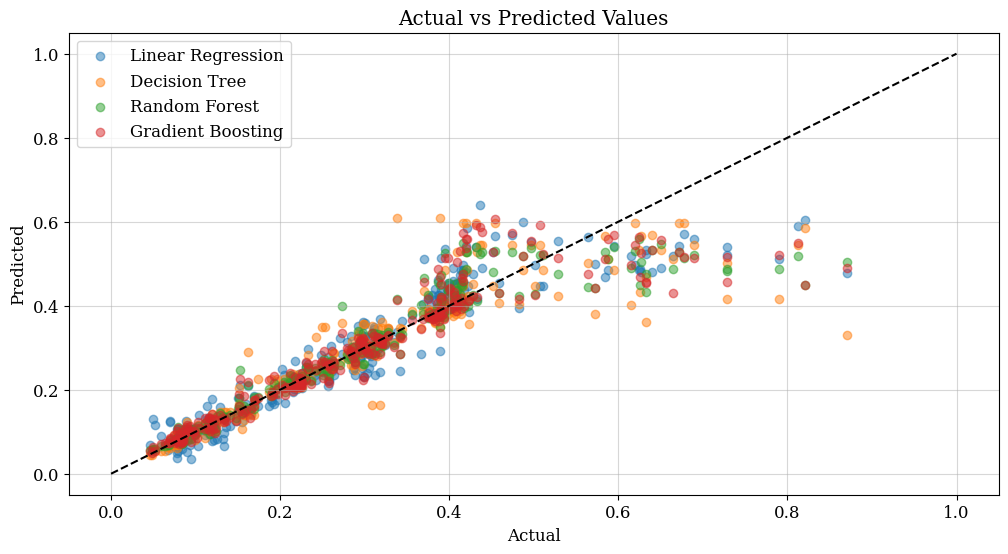

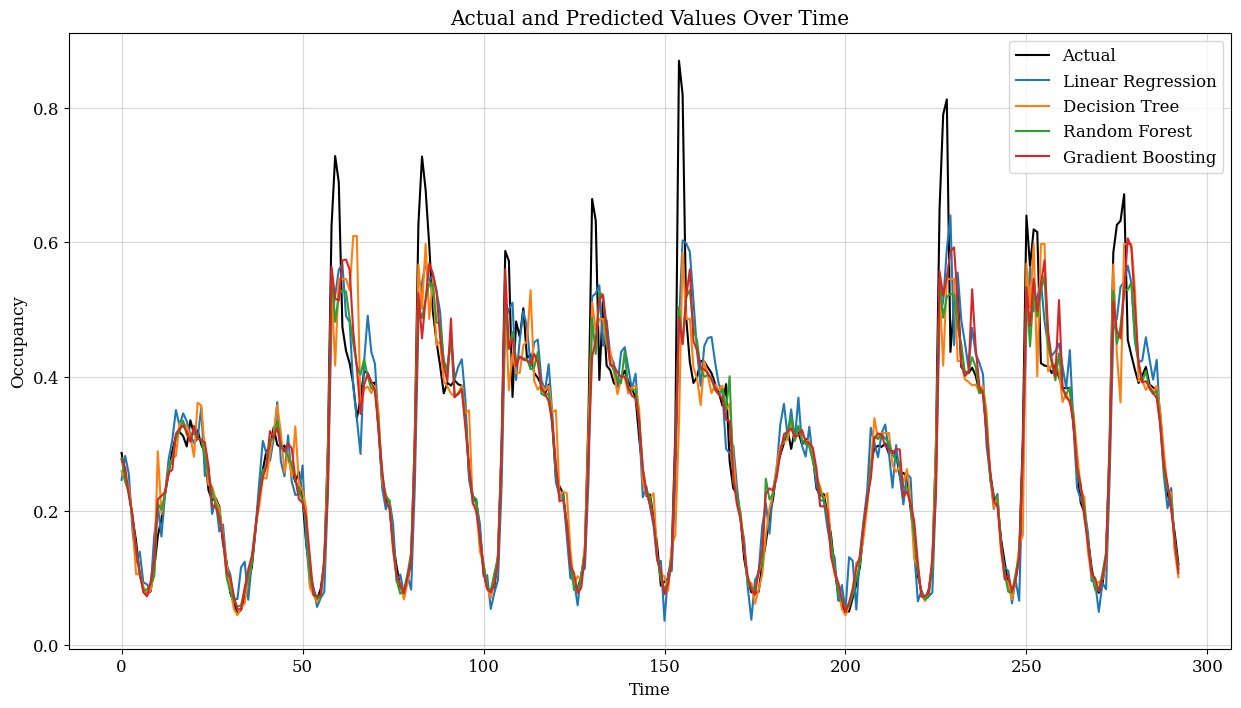

In [ ]:
# Scatter plot for actual vs predicted values
plt.figure(figsize=(12, 6))
for name, prediction in predictions.items():
    plt.scatter(test_Y, prediction, alpha=0.5, label=name)
plt.plot([0, 1], [0, 1], '--', color='black')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

# Line plot for actual and predicted values over time
plt.figure(figsize=(15, 8))
plt.plot(test_Y, label='Actual', color='black')
for name, prediction in predictions.items():
    plt.plot(prediction, label=name)
plt.xlabel('Time')
plt.ylabel('Occupancy')
plt.title('Actual and Predicted Values Over Time')
plt.legend()
plt.show()


# **SVR**

SVR - MAE: 0.0592, MSE: 0.0066, RMSE: 0.0812


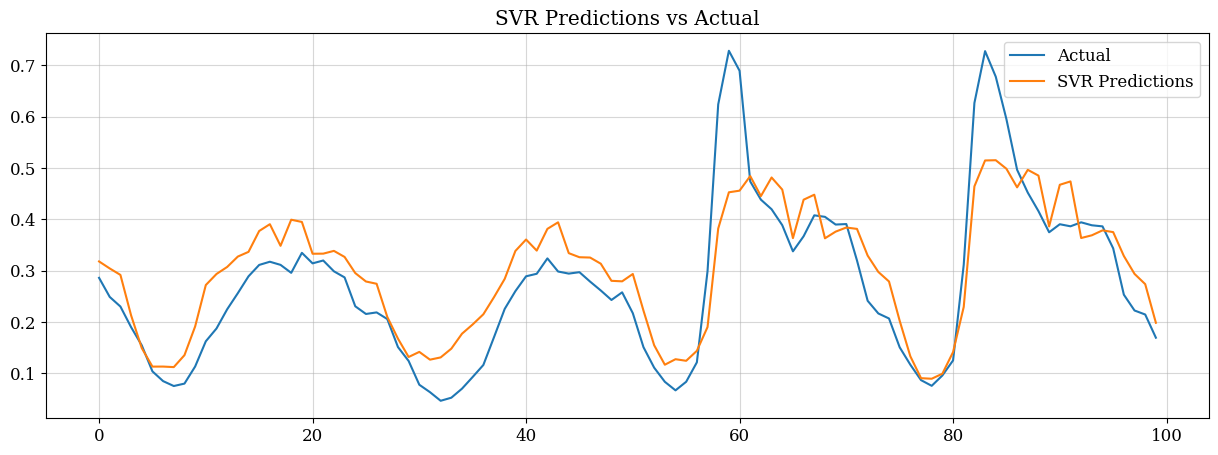

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns

# Train SVR model
svr_model = SVR()
svr_model.fit(train_X.reshape(train_X.shape[0], -1), train_Y.ravel())

# Predict with SVR model
svr_predictions = svr_model.predict(test_X.reshape(test_X.shape[0], -1))

# Evaluate SVR model
svr_mae = mean_absolute_error(test_Y, svr_predictions)
svr_mse = mean_squared_error(test_Y, svr_predictions)
svr_rmse = np.sqrt(svr_mse)

print(f"SVR - MAE: {svr_mae:.4f}, MSE: {svr_mse:.4f}, RMSE: {svr_rmse:.4f}")

# Plotting predictions
plt.figure(figsize=(15, 5))
plt.plot(test_Y[:100], label='Actual')
plt.plot(svr_predictions[:100], label='SVR Predictions')
plt.title('SVR Predictions vs Actual')
plt.legend()
plt.show()


# **KNN**

KNN - MAE: 0.0315, MSE: 0.0045, RMSE: 0.0669


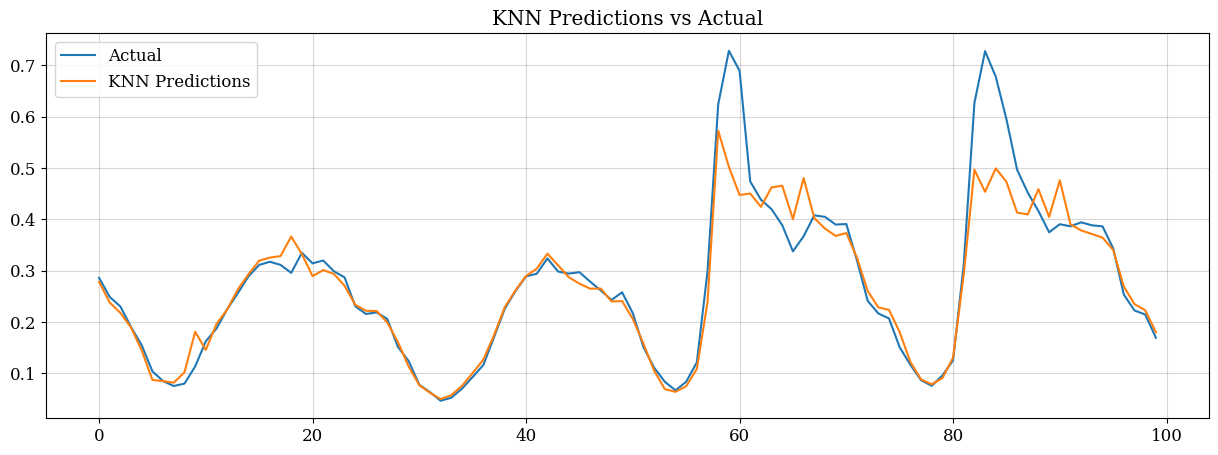

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(train_X.reshape(train_X.shape[0], -1), train_Y)

# Predict with KNN model
knn_predictions = knn_model.predict(test_X.reshape(test_X.shape[0], -1))

# Evaluate KNN model
knn_mae = mean_absolute_error(test_Y, knn_predictions)
knn_mse = mean_squared_error(test_Y, knn_predictions)
knn_rmse = np.sqrt(knn_mse)

print(f"KNN - MAE: {knn_mae:.4f}, MSE: {knn_mse:.4f}, RMSE: {knn_rmse:.4f}")

# Plotting predictions
plt.figure(figsize=(15, 5))
plt.plot(test_Y[:100], label='Actual')
plt.plot(knn_predictions[:100], label='KNN Predictions')
plt.title('KNN Predictions vs Actual')
plt.legend()
plt.show()


KNN - MAE: 0.0310, MSE: 0.0044, RMSE: 0.0666


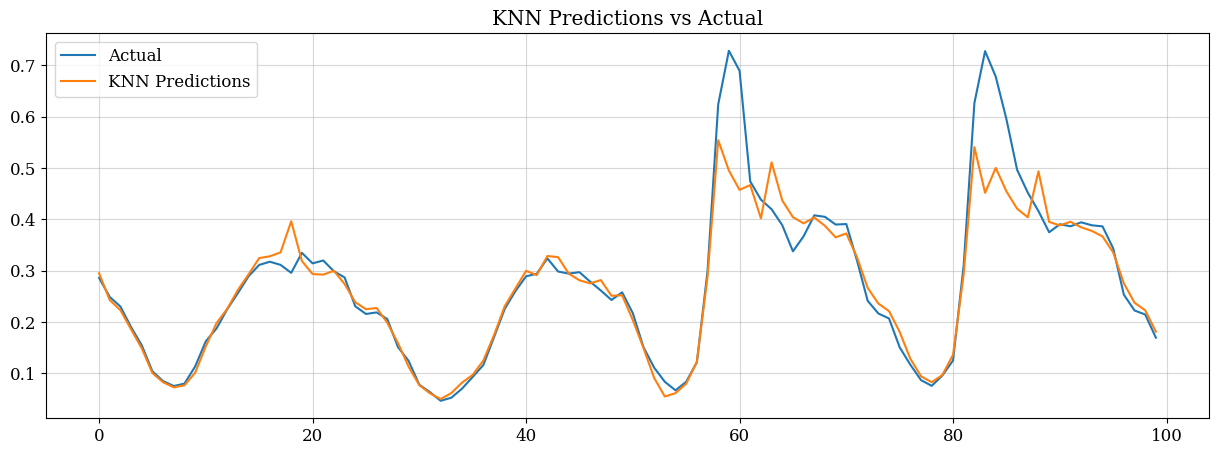

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train KNN model
knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(train_X.reshape(train_X.shape[0], -1), train_Y)

# Predict with KNN model
knn_predictions = knn_model.predict(test_X.reshape(test_X.shape[0], -1))

# Evaluate KNN model
knn_mae = mean_absolute_error(test_Y, knn_predictions)
knn_mse = mean_squared_error(test_Y, knn_predictions)
knn_rmse = np.sqrt(knn_mse)

print(f"KNN - MAE: {knn_mae:.4f}, MSE: {knn_mse:.4f}, RMSE: {knn_rmse:.4f}")

# Plotting predictions
plt.figure(figsize=(15, 5))
plt.plot(test_Y[:100], label='Actual')
plt.plot(knn_predictions[:100], label='KNN Predictions')
plt.title('KNN Predictions vs Actual')
plt.legend()
plt.show()

# **XGBoost Model**

XGBoost - MAE: 0.0295, MSE: 0.0043, RMSE: 0.0654


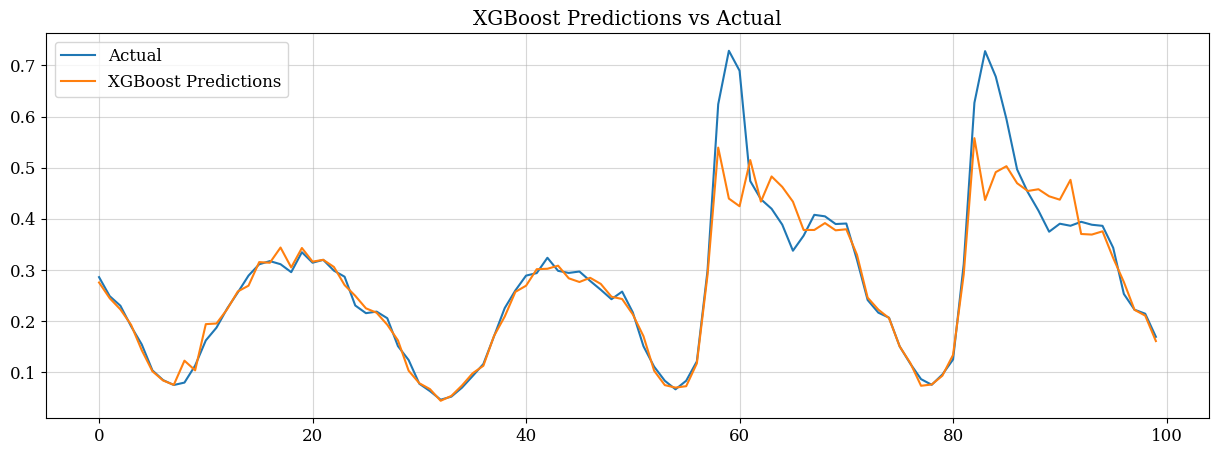

In [ ]:
import xgboost as xgb

# Train XGBoost model
xgb_model = xgb.XGBRegressor()
xgb_model.fit(train_X.reshape(train_X.shape[0], -1), train_Y)

# Predict with XGBoost model
xgb_predictions = xgb_model.predict(test_X.reshape(test_X.shape[0], -1))

# Evaluate XGBoost model
xgb_mae = mean_absolute_error(test_Y, xgb_predictions)
xgb_mse = mean_squared_error(test_Y, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)

print(f"XGBoost - MAE: {xgb_mae:.4f}, MSE: {xgb_mse:.4f}, RMSE: {xgb_rmse:.4f}")

# Plotting predictions
plt.figure(figsize=(15, 5))
plt.plot(test_Y[:100], label='Actual')
plt.plot(xgb_predictions[:100], label='XGBoost Predictions')
plt.title('XGBoost Predictions vs Actual')
plt.legend()
plt.show()


# **CNN**

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.1056 - root_mean_squared_error: 0.3129 - val_loss: 0.0086 - val_root_mean_squared_error: 0.0926
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0109 - root_mean_squared_error: 0.1043 - val_loss: 0.0051 - val_root_mean_squared_error: 0.0716
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0076 - root_mean_squared_error: 0.0870 - val_loss: 0.0068 - val_root_mean_squared_error: 0.0826
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0068 - root_mean_squared_error: 0.0825 - val_loss: 0.0061 - val_root_mean_squared_error: 0.0781
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0059 - root_mean_squared_error: 0.0769 - val_loss: 0.0043 - val_root_mean_squared_error: 0.0658
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0058 - root_mean_squared_error: 0.0762 - val_loss: 0.0040 - val_root_mean_squared_error: 0.0633
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss:

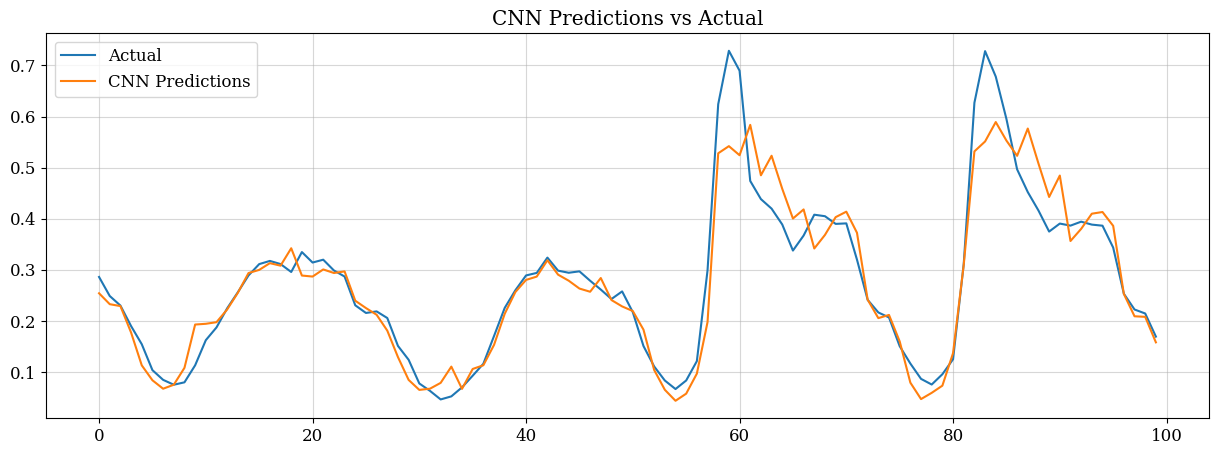

In [ ]:
from keras.models import Sequential
from keras.layers import Conv1D, Flatten, Dense
from keras.metrics import RootMeanSquaredError

# Define CNN model
cnn_model = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(train_X.shape[1], train_X.shape[2]), padding='same'), # Use 'same' padding to keep the output size same as input
    Flatten(),
    Dense(100, activation='relu'),
    Dense(train_Y.shape[1])
])

cnn_model.compile(optimizer='adam', loss='mse', metrics=[RootMeanSquaredError()])

# Train CNN model
cnn_model.fit(train_X, train_Y, epochs=50, batch_size=64, validation_split=0.2)

# Predict with CNN model
cnn_predictions = cnn_model.predict(test_X)

# Evaluate CNN model
cnn_mae = mean_absolute_error(test_Y, cnn_predictions)
cnn_mse = mean_squared_error(test_Y, cnn_predictions)
cnn_rmse = np.sqrt(cnn_mse)

print(f"CNN - MAE: {cnn_mae:.4f}, MSE: {cnn_mse:.4f}, RMSE: {cnn_rmse:.4f}")

# Plotting predictions
plt.figure(figsize=(15, 5))
plt.plot(test_Y[:100], label='Actual')
plt.plot(cnn_predictions[:100], label='CNN Predictions')
plt.title('CNN Predictions vs Actual')
plt.legend()
plt.show()

# **Gated Recurrent Unit (GRU) Model**

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - loss: 0.0274 - root_mean_squared_error: 0.1619 - val_loss: 0.0053 - val_root_mean_squared_error: 0.0725
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0085 - root_mean_squared_error: 0.0921 - val_loss: 0.0052 - val_root_mean_squared_error: 0.0719
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0075 - root_mean_squared_error: 0.0865 - val_loss: 0.0055 - val_root_mean_squared_error: 0.0740
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0062 - root_mean_squared_error: 0.0788 - val_loss: 0.0044 - val_root_mean_squared_error: 0.0665
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0070 - root_mean_squared_error: 0.0835 - val_loss: 0.0054 - val_root_mean_squared_error: 0.0733
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0063 - root_mean_squared_error: 0.0795 - val_loss: 0.0053 - val_root_mean_squared_error: 0.0727
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - loss: 0.0064

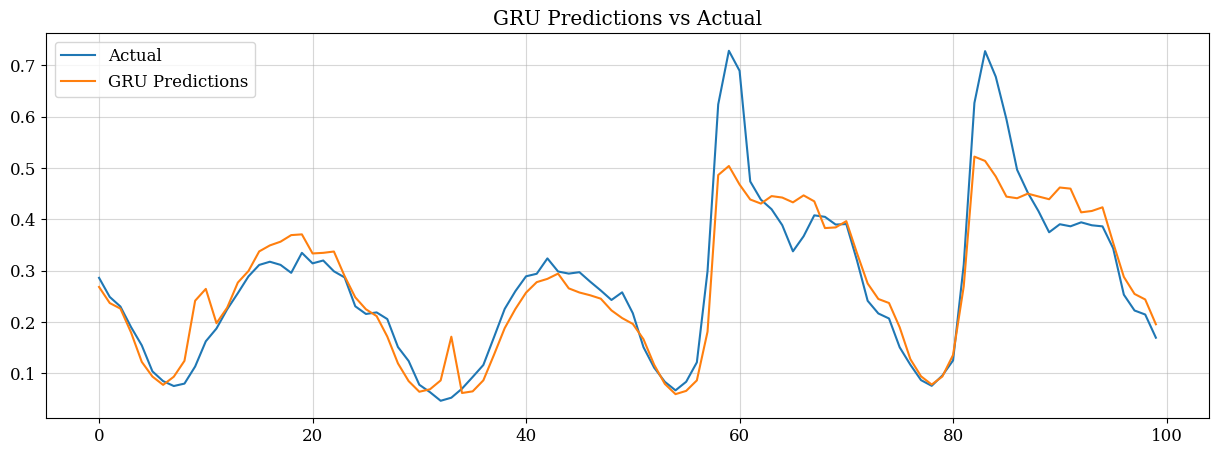

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.metrics import RootMeanSquaredError

# Define GRU model
gru_model = Sequential([
    GRU(256, input_shape=(train_X.shape[1], train_X.shape[2]), return_sequences=False),
    Dense(1)  # Change the output layer to have a single neuron
])

gru_model.compile(optimizer='adam', loss='mse', metrics=[RootMeanSquaredError()])

# Train GRU model
gru_model.fit(train_X, train_Y, epochs=50, batch_size=64, validation_split=0.2)

# Predict with GRU model
gru_predictions = gru_model.predict(test_X)

# Evaluate GRU model
gru_mae = mean_absolute_error(test_Y, gru_predictions)
gru_mse = mean_squared_error(test_Y, gru_predictions)
gru_rmse = np.sqrt(gru_mse)

print(f"GRU - MAE: {gru_mae:.4f}, MSE: {gru_mse:.4f}, RMSE: {gru_rmse:.4f}")

# Plotting predictions
plt.figure(figsize=(15, 5))
plt.plot(test_Y[:100], label='Actual')
plt.plot(gru_predictions[:100], label='GRU Predictions')
plt.title('GRU Predictions vs Actual')
plt.legend()
plt.show()

# **LSTM**

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 372ms/step - loss: 0.0338 - root_mean_squared_error: 0.1811 - val_loss: 0.0075 - val_root_mean_squared_error: 0.0867
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 247ms/step - loss: 0.0093 - root_mean_squared_error: 0.0964 - val_loss: 0.0068 - val_root_mean_squared_error: 0.0825
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 291ms/step - loss: 0.0092 - root_mean_squared_error: 0.0954 - val_loss: 0.0066 - val_root_mean_squared_error: 0.0810
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 344ms/step - loss: 0.0074 - root_mean_squared_error: 0.0859 - val_loss: 0.0069 - val_root_mean_squared_error: 0.0829
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 300ms/step - loss: 0.0073 - root_mean_squared_error: 0.0855 - val_loss: 0.0067 - val_root_mean_squared_error: 0.0820
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 352ms/step - loss: 0.0059 - root_mean_squared_error: 0.0770 - val_loss: 0.0056 - val_root_mean_squared_error: 0.0748
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 281ms/step

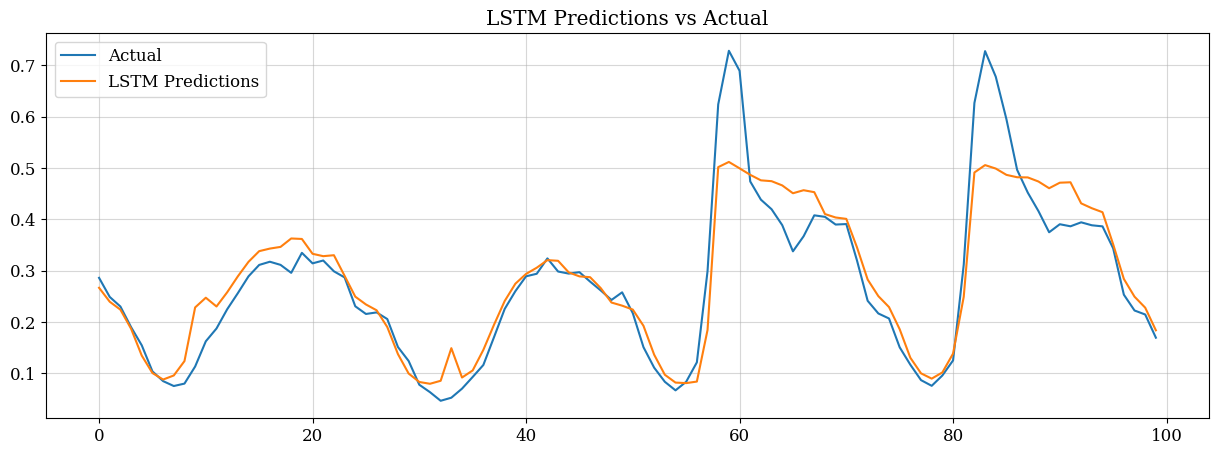

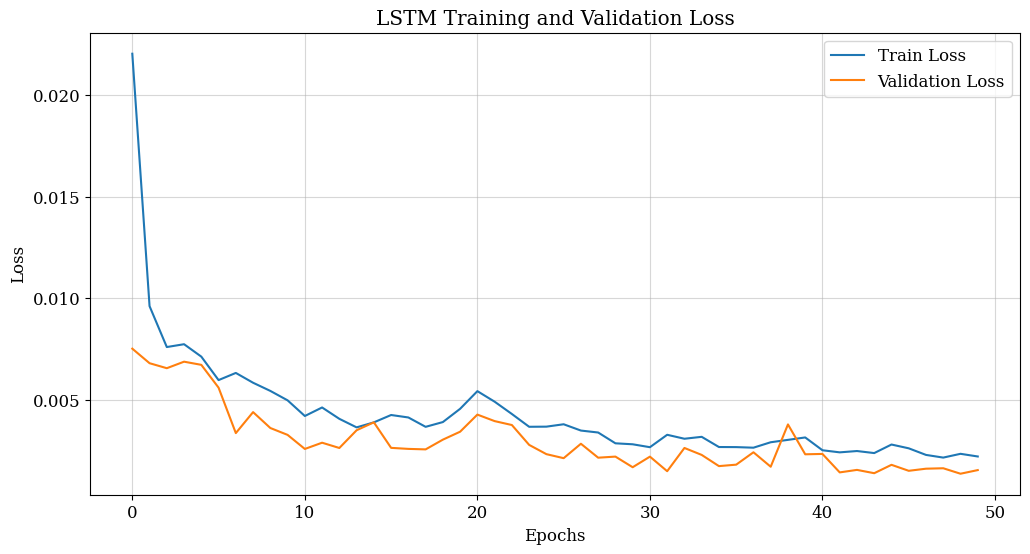

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.metrics import RootMeanSquaredError

# Define LSTM model
lstm_model = Sequential([
    LSTM(256, return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])),
    LSTM(256, return_sequences=False),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(train_Y.shape[1], activation='linear'),
])

lstm_model.compile(loss='mse', optimizer='adam', metrics=[RootMeanSquaredError()])

# Train LSTM model
history = lstm_model.fit(train_X, train_Y, epochs=50, batch_size=64, validation_split=0.2)

# Predict with LSTM model
lstm_predictions = lstm_model.predict(test_X)

# Evaluate LSTM model
lstm_mae = mean_absolute_error(test_Y, lstm_predictions)
lstm_mse = mean_squared_error(test_Y, lstm_predictions)
lstm_rmse = np.sqrt(lstm_mse)

print(f"LSTM - MAE: {lstm_mae:.4f}, MSE: {lstm_mse:.4f}, RMSE: {lstm_rmse:.4f}")

# Plotting predictions
plt.figure(figsize=(15, 5))
plt.plot(test_Y[:100], label='Actual')
plt.plot(lstm_predictions[:100], label='LSTM Predictions')
plt.title('LSTM Predictions vs Actual')
plt.legend()
plt.show()

# Plotting model summary
plot_model(lstm_model, show_shapes=True, show_layer_names=True)

# Plotting validation curves
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 24, 256)             │         290,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 256)                 │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,646,533 (10.10 MB)

 Trainable params: 882,177 (3.37 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,764,356 (6.73 MB)

# **Hybrid Models**
# **1. CNN-LSTM Model**

In [ ]:
from keras.models import Model
from keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM, Input, Dense, Reshape

# Define CNN-LSTM model
input_layer = Input(shape=(train_X.shape[1], train_X.shape[2]))
conv1 = Conv1D(filters=64, kernel_size=2, activation='relu')(input_layer)
conv2 = Conv1D(filters=64, kernel_size=2, activation='relu')(conv1)
pooling = MaxPooling1D(pool_size=2)(conv2)
# Reshape to add the time dimension back
reshape = Reshape((pooling.shape[1], pooling.shape[2]))(pooling)  # Keep the features dimension
lstm = LSTM(100, activation='relu')(reshape)
# Change the number of units in the output layer to 1 to match test_Y
output_layer = Dense(1)(lstm) # Modified line

cnn_lstm_model = Model(inputs=input_layer, outputs=output_layer)
cnn_lstm_model.compile(optimizer='adam', loss='mse', metrics=[RootMeanSquaredError()])

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0431 - root_mean_squared_error: 0.2044 - val_loss: 0.0218 - val_root_mean_squared_error: 0.1476
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0160 - root_mean_squared_error: 0.1265 - val_loss: 0.0140 - val_root_mean_squared_error: 0.1184
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0114 - root_mean_squared_error: 0.1066 - val_loss: 0.0091 - val_root_mean_squared_error: 0.0953
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0094 - root_mean_squared_error: 0.0968 - val_loss: 0.0096 - val_root_mean_squared_error: 0.0980
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0087 - root_mean_squared_error: 0.0931 - val_loss: 0.0068 - val_root_mean_squared_error: 0.0825
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0072 - root_mean_squared_error: 0.0850 - val_loss: 0.0069 - val_root_mean_squared_error: 0.0831
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss:

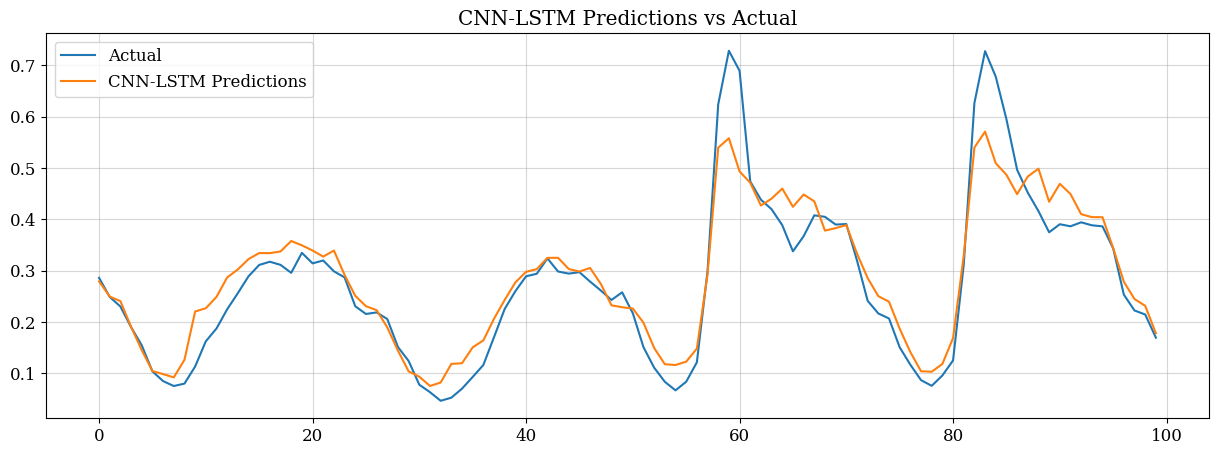

In [ ]:
# Train CNN-LSTM model
cnn_lstm_model.fit(train_X, train_Y, epochs=50, batch_size=64, validation_split=0.2)

# Predict with CNN-LSTM model
cnn_lstm_predictions = cnn_lstm_model.predict(test_X)

# Evaluate CNN-LSTM model
cnn_lstm_mae = mean_absolute_error(test_Y, cnn_lstm_predictions)
cnn_lstm_mse = mean_squared_error(test_Y, cnn_lstm_predictions)
cnn_lstm_rmse = np.sqrt(cnn_lstm_mse)

print(f"CNN-LSTM - MAE: {cnn_lstm_mae:.4f}, MSE: {cnn_lstm_mse:.4f}, RMSE: {cnn_lstm_rmse:.4f}")

# Plotting predictions
plt.figure(figsize=(15, 5))
plt.plot(test_Y[:100], label='Actual')
plt.plot(cnn_lstm_predictions[:100], label='CNN-LSTM Predictions')
plt.title('CNN-LSTM Predictions vs Actual')
plt.legend()
plt.show()


# **2. GRU-CNN Model**

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0141 - root_mean_squared_error: 0.1181 - val_loss: 0.0079 - val_root_mean_squared_error: 0.0890
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0062 - root_mean_squared_error: 0.0784 - val_loss: 0.0041 - val_root_mean_squared_error: 0.0639
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0064 - root_mean_squared_error: 0.0792 - val_loss: 0.0044 - val_root_mean_squared_error: 0.0662
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0045 - root_mean_squared_error: 0.0673 - val_loss: 0.0028 - val_root_mean_squared_error: 0.0530
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0033 - root_mean_squared_error: 0.0572 - val_loss: 0.0029 - val_root_mean_squared_error: 0.0535
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0027 - root_mean_squared_error: 0.0520 - val_loss: 0.0052 - val_root_mean_squared_error: 0.0723
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss

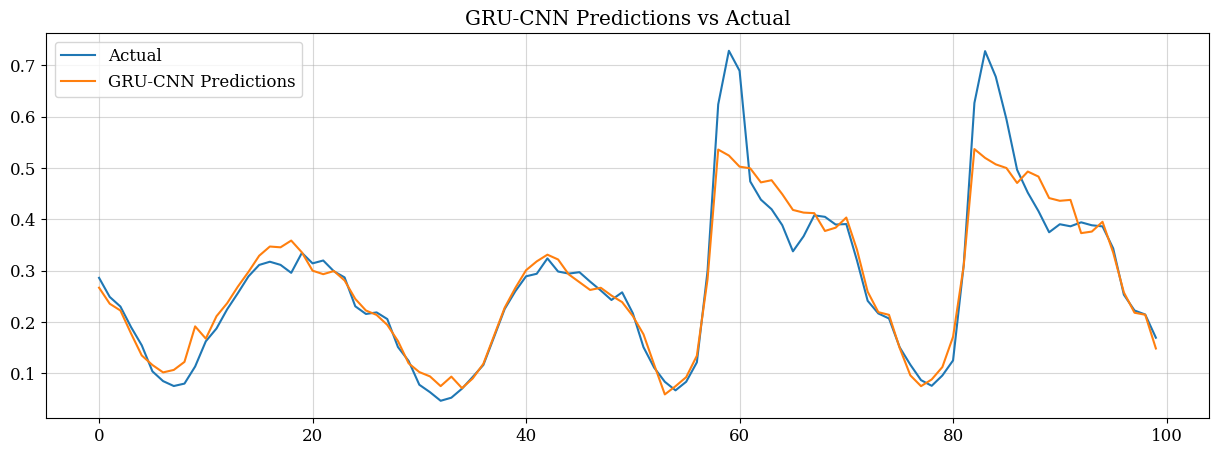

In [ ]:
from keras.models import Model
from keras.layers import GRU, Conv1D, MaxPooling1D, Flatten, Input, Dense

# Define GRU-CNN model
input_layer = Input(shape=(train_X.shape[1], train_X.shape[2]))
gru = GRU(100, activation='relu', return_sequences=True)(input_layer)
conv1 = Conv1D(filters=64, kernel_size=2, activation='relu')(gru)
pooling = MaxPooling1D(pool_size=2)(conv1)
flatten = Flatten()(pooling)
# Change number of units in the output layer to 1
output_layer = Dense(1)(flatten) # Modified line

gru_cnn_model = Model(inputs=input_layer, outputs=output_layer)
gru_cnn_model.compile(optimizer='adam', loss='mse', metrics=[RootMeanSquaredError()])

# Train GRU-CNN model
gru_cnn_model.fit(train_X, train_Y, epochs=50, batch_size=64, validation_split=0.2)

# Predict with GRU-CNN model
gru_cnn_predictions = gru_cnn_model.predict(test_X)

# Evaluate GRU-CNN model
gru_cnn_mae = mean_absolute_error(test_Y, gru_cnn_predictions)
gru_cnn_mse = mean_squared_error(test_Y, gru_cnn_predictions)
gru_cnn_rmse = np.sqrt(gru_cnn_mse)

print(f"GRU-CNN - MAE: {gru_cnn_mae:.4f}, MSE: {gru_cnn_mse:.4f}, RMSE: {gru_cnn_rmse:.4f}")

# Plotting predictions
plt.figure(figsize=(15, 5))
plt.plot(test_Y[:100], label='Actual')
plt.plot(gru_cnn_predictions[:100], label='GRU-CNN Predictions')
plt.title('GRU-CNN Predictions vs Actual')
plt.legend()
plt.show()

# **Visualizing Evaluation Metrics**

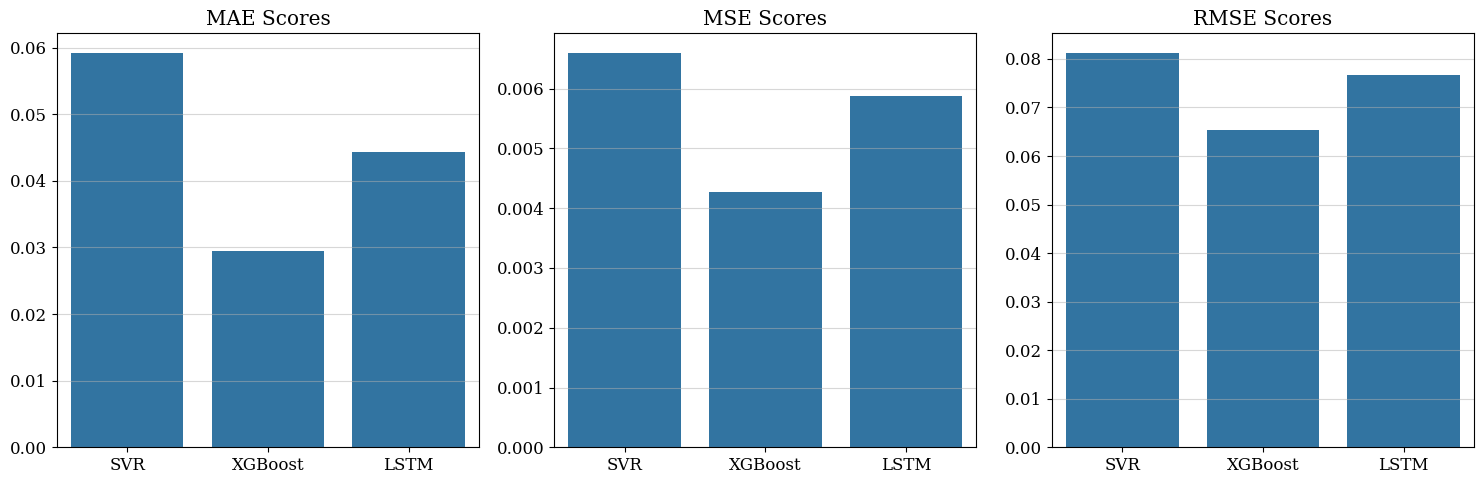

In [ ]:
# Define metrics for plotting
models = ['SVR', 'XGBoost', 'LSTM']
mae_scores = [svr_mae, xgb_mae, lstm_mae]
mse_scores = [svr_mse, xgb_mse, lstm_mse]
rmse_scores = [svr_rmse, xgb_rmse, lstm_rmse]

# Plotting metrics
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.barplot(x=models, y=mae_scores)
plt.title('MAE Scores')

plt.subplot(1, 3, 2)
sns.barplot(x=models, y=mse_scores)
plt.title('MSE Scores')

plt.subplot(1, 3, 3)
sns.barplot(x=models, y=rmse_scores)
plt.title('RMSE Scores')

plt.tight_layout()
plt.show()


# **Simple Graph Convolutional Network (GCN)**

In [ ]:
# a simple Graph Convolutional Network (GCN)
!pip install torch torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 665.3 kB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_6

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# Load the Cora dataset
dataset = Planetoid(root='/tmp/Cora', name='Cora')

# Get the first graph object in the dataset
data = dataset[0]
print(data)

Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


Done!


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)
model = GCN()
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


In [ ]:
#Train the model:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Training function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(dataset[0])
    loss = F.nll_loss(out[dataset[0].train_mask], dataset[0].y[dataset[0].train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()
    # Testing function
def test():
    model.eval()
    logits, accs = model(dataset[0]), []
    for _, mask in dataset[0]('train_mask', 'val_mask', 'test_mask'):
        pred = logits[mask].max(1)[1]
        acc = pred.eq(dataset[0].y[mask]).sum().item() / mask.sum().item()
        accs.append(acc)
    return accs

# Training loop
for epoch in range(200):
    loss = train()
    train_acc, val_acc, test_acc = test()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')

Epoch: 000, Loss: 1.9389, Train Acc: 0.6286, Val Acc: 0.2660, Test Acc: 0.3020
Epoch: 001, Loss: 1.8045, Train Acc: 0.7929, Val Acc: 0.4240, Test Acc: 0.4330
Epoch: 002, Loss: 1.6438, Train Acc: 0.8214, Val Acc: 0.4780, Test Acc: 0.4800
Epoch: 003, Loss: 1.5154, Train Acc: 0.8429, Val Acc: 0.5020, Test Acc: 0.4890
Epoch: 004, Loss: 1.3935, Train Acc: 0.8643, Val Acc: 0.5480, Test Acc: 0.5430
Epoch: 005, Loss: 1.2374, Train Acc: 0.8786, Val Acc: 0.5920, Test Acc: 0.5950
Epoch: 006, Loss: 1.1077, Train Acc: 0.9357, Val Acc: 0.6240, Test Acc: 0.6390
Epoch: 007, Loss: 0.9752, Train Acc: 0.9571, Val Acc: 0.6680, Test Acc: 0.6670
Epoch: 008, Loss: 0.8819, Train Acc: 0.9714, Val Acc: 0.6880, Test Acc: 0.6940
Epoch: 009, Loss: 0.7908, Train Acc: 0.9786, Val Acc: 0.7200, Test Acc: 0.7120
Epoch: 010, Loss: 0.7004, Train Acc: 0.9857, Val Acc: 0.7320, Test Acc: 0.7310
Epoch: 011, Loss: 0.5856, Train Acc: 0.9857, Val Acc: 0.7420, Test Acc: 0.7470
Epoch: 012, Loss: 0.5371, Train Acc: 0.9857, Val Acc